# Brain2 Radial Kernel Training

Focused notebook for `data_brain2/kaggle_3m`.

This keeps only the workflow needed for a single radial kernel:

1. Build paired image/mask records from the LGG MRI `.tif` dataset.
2. Split by patient folder to avoid slice leakage.
3. Sample balanced tumor and non-tumor patches from masks.
4. Train one signed radial kernel profile `f(r)` with the same progressive/smooth regularized style used near the end of `radial_single_kernel_fi_optimization_tissue_mask.ipynb`.
5. Visualize the learned kernel, radial profile, validation curves, and a heatmap overlay on a full MRI slice.

Nothing in this notebook runs automatically beyond the cell you execute.

In [31]:
from pathlib import Path
import json
import os
import shutil

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from scipy.ndimage import binary_dilation, binary_erosion, gaussian_filter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

# Dataset
DATASET_ROOT = Path("data_brain2/kaggle_3m")
PATCH_OUTPUT_ROOT = Path("data_brain2/patches_radial_v4_p32_center_matched")
OUT_DIR = Path("results/brain2_radial_v4_center_matched")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Corrected localization-oriented patch generation. The new cache path preserves old patches.
# Leave RUN_PATCH_PREP=True for the first run, then set it False to reuse the generated cache.
RUN_PATCH_PREP = True
CLEAR_PATCH_OUTPUT_BEFORE_PREP = True
PATCH_SIZE = 32
N_POS_PER_IMAGE = 12
N_NEG_PER_IMAGE = 12
MAX_TRIES_PER_IMAGE = 300
CENTER_LABEL_SIZE = 9          # labels describe the central region, matching heatmap centers
MIN_POS_CENTER_COVERAGE = 0.50
MAX_NEG_CENTER_COVERAGE = 0.0
MIRRORED_NEG_FRACTION = 0.50   # contralateral anatomy matched to tumor coordinates
NEAR_NEG_FRACTION = 0.25       # boundary hard negatives; remainder is diverse same-slice tissue
NEAR_NEG_DILATION = 20
MIN_TISSUE_FRACTION = 0.40
TISSUE_THRESHOLD = 5
MASK_THRESHOLD = 0
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15
SPLIT_SEED = 42
MAX_SOURCE_IMAGES = None  # e.g. 1200 for a quick run; None uses all pairs
MAX_PATCHES_TRAIN_PER_CLASS = 3000
MAX_PATCHES_VAL_PER_CLASS = 1000
MAX_PATCHES_TEST_PER_CLASS = 1000

# Training
RESIZE_PATCH = 32
MAX_PER_CLASS = None  # None loads all generated patches; set smaller for a quick run
KERNEL_SIZE = 31
LEARNED_RADIUS_MAX = 15
NUM_RADIAL_KERNELS = 16
HEAD_HIDDEN_DIM = 32
HEAD_DROPOUT = 0.10
STANDARDIZE_PATCHES = True
FEATURE_POOL_SIZE = 9          # pool kernel responses only where the center label is defined
FEATURE_MODE = "multi"  # "multi" uses mean_abs + abs_max + signed_topk from one radial kernel
RESPONSE_MODE = "signed_topk"  # used only when FEATURE_MODE="single"
SIGNED_TOPK_FRAC = 0.10        # stable top-k within the small central response region
EPOCHS = 40
BATCH_SIZE = 128
LR_PROFILE = 1e-2
LR_HEAD = 3e-3
LAMBDA_SMOOTH = 1e-4
LAMBDA_CURVATURE = 1e-4
LAMBDA_ANCHOR = 1e-4
LAMBDA_SCALE = 1e-4
THRESHOLD_GRID_SIZE = 181

# Heatmap
EXAMPLE_IMAGE_PATH = None  # None picks the first positive-mask test/val/train slice
HEATMAP_SMOOTH_SIGMA = 1.2
EXACT_HEATMAP_STRIDE = 4
HEATMAP_N_EXAMPLES = 6
DENSE_OVERLAY_ALPHA = 0.42
SAVE_ARTIFACTS = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(min(8, max(1, os.cpu_count() or 1)))
print(f"Device: {DEVICE}")

Device: cuda


In [32]:
def image_to_gray_float(path: Path) -> np.ndarray:
    arr = np.array(Image.open(path).convert("L"), dtype=np.float32)
    return arr / 255.0


def mask_to_bool(path: Path, shape=None) -> np.ndarray:
    mask = np.array(Image.open(path).convert("L"), dtype=np.uint8)
    if shape is not None and mask.shape != shape:
        mask_img = Image.fromarray(mask).resize((shape[1], shape[0]), resample=Image.Resampling.NEAREST)
        mask = np.array(mask_img, dtype=np.uint8)
    return mask > int(MASK_THRESHOLD)


def list_image_mask_pairs(dataset_root: Path):
    dataset_root = Path(dataset_root)
    pairs = []
    for patient_dir in sorted(p for p in dataset_root.iterdir() if p.is_dir()):
        for image_path in sorted(patient_dir.glob("*.tif")):
            if image_path.name.endswith("_mask.tif"):
                continue
            mask_path = image_path.with_name(f"{image_path.stem}_mask.tif")
            if mask_path.exists():
                pairs.append({
                    "patient": patient_dir.name,
                    "image": image_path,
                    "mask": mask_path,
                    "stem": image_path.stem,
                })
    if not pairs:
        raise FileNotFoundError(f"No image/mask .tif pairs found under {dataset_root}")
    return pairs


def split_patients(pairs, train_frac=0.70, val_frac=0.15, seed=42):
    patients = sorted({row["patient"] for row in pairs})
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(patients))
    n_train = int(round(train_frac * len(patients)))
    n_val = int(round(val_frac * len(patients)))
    split_by_patient = {}
    for pos, idx in enumerate(order):
        if pos < n_train:
            split = "train"
        elif pos < n_train + n_val:
            split = "val"
        else:
            split = "test"
        split_by_patient[patients[idx]] = split
    return split_by_patient


def crop_with_padding(arr: np.ndarray, cy: int, cx: int, patch_size: int, pad_value: float = 0.0):
    half = patch_size // 2
    y0, y1 = cy - half, cy - half + patch_size
    x0, x1 = cx - half, cx - half + patch_size
    out = np.full((patch_size, patch_size), pad_value, dtype=arr.dtype)
    sy0, sy1 = max(0, y0), min(arr.shape[0], y1)
    sx0, sx1 = max(0, x0), min(arr.shape[1], x1)
    oy0, ox0 = sy0 - y0, sx0 - x0
    out[oy0:oy0 + (sy1 - sy0), ox0:ox0 + (sx1 - sx0)] = arr[sy0:sy1, sx0:sx1]
    return out


def sample_class_patches(
    img: np.ndarray,
    tumor_mask: np.ndarray,
    candidate_mask: np.ndarray,
    n_patches: int,
    patch_size: int,
    max_tries: int,
    min_tissue_fraction: float,
    is_positive: bool,
    rng=None,
):
    yy, xx = np.nonzero(candidate_mask)
    if len(yy) == 0 or n_patches <= 0:
        return []

    tissue = img > (float(TISSUE_THRESHOLD) / 255.0)
    rng = np.random.default_rng() if rng is None else rng
    patches = []
    for _ in range(max_tries):
        if len(patches) >= n_patches:
            break
        j = int(rng.integers(0, len(yy)))
        cy, cx = int(yy[j]), int(xx[j])
        patch = crop_with_padding(img, cy, cx, patch_size, pad_value=0.0)
        tumor_patch = crop_with_padding(tumor_mask.astype(np.float32), cy, cx, patch_size, pad_value=0.0) > 0.5
        tissue_patch = crop_with_padding(tissue.astype(np.float32), cy, cx, patch_size, pad_value=0.0) > 0.5

        # A heatmap score is assigned to the patch center, so train its label from
        # the same central region instead of labeling the whole 32x32 footprint.
        center_size = min(int(CENTER_LABEL_SIZE), int(patch_size))
        c0 = (int(patch_size) - center_size) // 2
        center_tumor_frac = float(tumor_patch[c0:c0+center_size, c0:c0+center_size].mean())
        tissue_frac = float(tissue_patch.mean())
        if tissue_frac < float(min_tissue_fraction):
            continue
        if is_positive and center_tumor_frac < float(MIN_POS_CENTER_COVERAGE):
            continue
        if (not is_positive) and center_tumor_frac > float(MAX_NEG_CENTER_COVERAGE):
            continue
        patches.append((patch * 255.0).clip(0, 255).astype(np.uint8))
    return patches


def prepare_patch_splits():
    if CLEAR_PATCH_OUTPUT_BEFORE_PREP and PATCH_OUTPUT_ROOT.exists():
        shutil.rmtree(PATCH_OUTPUT_ROOT)

    pairs = list_image_mask_pairs(DATASET_ROOT)
    split_by_patient = split_patients(pairs, TRAIN_FRAC, VAL_FRAC, SPLIT_SEED)

    rng = np.random.default_rng(SPLIT_SEED)
    if MAX_SOURCE_IMAGES is not None and len(pairs) > int(MAX_SOURCE_IMAGES):
        pairs = [pairs[i] for i in rng.permutation(len(pairs))[: int(MAX_SOURCE_IMAGES)]]
    # Avoid filling class caps from alphabetically early patients/slices.
    pairs = [pairs[i] for i in rng.permutation(len(pairs))]

    for split in ("train", "val", "test"):
        (PATCH_OUTPUT_ROOT / split / "inside").mkdir(parents=True, exist_ok=True)
        (PATCH_OUTPUT_ROOT / split / "outside").mkdir(parents=True, exist_ok=True)

    caps = {
        "train": MAX_PATCHES_TRAIN_PER_CLASS,
        "val": MAX_PATCHES_VAL_PER_CLASS,
        "test": MAX_PATCHES_TEST_PER_CLASS,
    }
    counts = {split: {"inside": 0, "outside": 0} for split in ("train", "val", "test")}

    def class_full(split, cls):
        cap = caps[split]
        return cap is not None and counts[split][cls] >= int(cap)

    for row in tqdm(pairs, desc="Sampling Brain2 patches"):
        split = split_by_patient[row["patient"]]
        if class_full(split, "inside") and class_full(split, "outside"):
            continue

        img = image_to_gray_float(row["image"])
        tumor = mask_to_bool(row["mask"], shape=img.shape)
        tissue = img > (float(TISSUE_THRESHOLD) / 255.0)
        # Critical shortcut control: both classes come only from tumor-positive slices.
        # This prevents the classifier from separating positive versus normal source slices.
        if not tumor.any():
            continue
        pos_candidates = tumor

        dilated = binary_dilation(tumor, iterations=int(NEAR_NEG_DILATION)) if tumor.any() else np.zeros_like(tumor)
        mirrored_negative = tissue & np.fliplr(tumor) & ~tumor
        near_negative = tissue & dilated & ~tumor
        far_negative = tissue & ~tumor

        n_pos = 0 if class_full(split, "inside") else int(N_POS_PER_IMAGE)
        n_neg = 0 if class_full(split, "outside") else int(N_NEG_PER_IMAGE)
        n_mirrored = int(round(n_neg * float(MIRRORED_NEG_FRACTION)))
        n_near = int(round(n_neg * float(NEAR_NEG_FRACTION)))
        n_far = max(0, n_neg - n_mirrored - n_near)

        pos_patches = sample_class_patches(img, tumor, pos_candidates, n_pos, PATCH_SIZE, MAX_TRIES_PER_IMAGE, MIN_TISSUE_FRACTION, True, rng)
        neg_patches = []
        neg_patches.extend(sample_class_patches(img, tumor, mirrored_negative, n_mirrored, PATCH_SIZE, MAX_TRIES_PER_IMAGE, MIN_TISSUE_FRACTION, False, rng))
        neg_patches.extend(sample_class_patches(img, tumor, near_negative, n_near, PATCH_SIZE, MAX_TRIES_PER_IMAGE, MIN_TISSUE_FRACTION, False, rng))
        if len(neg_patches) < n_neg:
            neg_patches.extend(sample_class_patches(img, tumor, far_negative, n_neg - len(neg_patches), PATCH_SIZE, MAX_TRIES_PER_IMAGE, MIN_TISSUE_FRACTION, False, rng))

        for cls, patches in (("inside", pos_patches), ("outside", neg_patches)):
            for patch in patches:
                if class_full(split, cls):
                    break
                idx = counts[split][cls]
                out_path = PATCH_OUTPUT_ROOT / split / cls / f"{cls}_{row['stem']}_{idx:05d}.tif"
                Image.fromarray(patch).save(out_path)
                counts[split][cls] += 1

    summary = {
        "dataset_root": str(DATASET_ROOT),
        "patch_output_root": str(PATCH_OUTPUT_ROOT),
        "n_pairs_used": len(pairs),
        "n_patients": len(set(split_by_patient)),
        "split_counts": counts,
        "config": {
            "patch_size": PATCH_SIZE,
            "n_pos_per_image": N_POS_PER_IMAGE,
            "n_neg_per_image": N_NEG_PER_IMAGE,
            "center_label_size": CENTER_LABEL_SIZE,
            "min_pos_center_coverage": MIN_POS_CENTER_COVERAGE,
            "max_neg_center_coverage": MAX_NEG_CENTER_COVERAGE,
            "same_tumor_positive_slices_for_both_classes": True,
            "mirrored_neg_fraction": MIRRORED_NEG_FRACTION,
            "near_neg_fraction": NEAR_NEG_FRACTION,
            "near_neg_dilation": NEAR_NEG_DILATION,
        },
    }
    PATCH_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    (PATCH_OUTPUT_ROOT / "prep_summary.json").write_text(json.dumps(summary, indent=2))
    return summary

pairs = list_image_mask_pairs(DATASET_ROOT)
print(f"Found {len(pairs)} image/mask pairs from {len({row['patient'] for row in pairs})} patients")
print(pairs[0])

Found 3929 image/mask pairs from 110 patients
{'patient': 'TCGA_CS_4941_19960909', 'image': PosixPath('data_brain2/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_1.tif'), 'mask': PosixPath('data_brain2/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_1_mask.tif'), 'stem': 'TCGA_CS_4941_19960909_1'}


In [33]:
print(f"Patch output root: {PATCH_OUTPUT_ROOT}")
print(f"Results output root: {OUT_DIR}")
print("If you changed patch-generation settings, set RUN_PATCH_PREP=True and regenerate patches before training.")


Patch output root: data_brain2/patches_radial_v4_p32_center_matched
Results output root: results/brain2_radial_v4_center_matched
If you changed patch-generation settings, set RUN_PATCH_PREP=True and regenerate patches before training.


In [34]:
if RUN_PATCH_PREP:
    prep_summary = prepare_patch_splits()
    print(json.dumps(prep_summary, indent=2))
else:
    print("RUN_PATCH_PREP=False. Set it to True and run this cell if patch folders are missing or stale.")
    for split in ("train", "val", "test"):
        for cls in ("inside", "outside"):
            n = len(list((PATCH_OUTPUT_ROOT / split / cls).glob("*.tif"))) if (PATCH_OUTPUT_ROOT / split / cls).exists() else 0
            print(f"{split:5s}/{cls:7s}: {n}")

Sampling Brain2 patches: 100%|██████████| 3929/3929 [00:04<00:00, 834.46it/s] 

{
  "dataset_root": "data_brain2/kaggle_3m",
  "patch_output_root": "data_brain2/patches_radial_v4_p32_center_matched",
  "n_pairs_used": 3929,
  "n_patients": 110,
  "split_counts": {
    "train": {
      "inside": 3000,
      "outside": 3000
    },
    "val": {
      "inside": 1000,
      "outside": 1000
    },
    "test": {
      "inside": 1000,
      "outside": 1000
    }
  },
  "config": {
    "patch_size": 32,
    "n_pos_per_image": 12,
    "n_neg_per_image": 12,
    "center_label_size": 9,
    "min_pos_center_coverage": 0.5,
    "max_neg_center_coverage": 0.0,
    "same_tumor_positive_slices_for_both_classes": true,
    "mirrored_neg_fraction": 0.5,
    "near_neg_fraction": 0.25,
    "near_neg_dilation": 20
  }
}


In [35]:
def load_patch_folder(folder: Path, resize: int | None = None, max_count: int | None = None):
    paths = sorted(Path(folder).glob("*.tif"))
    if max_count is not None:
        paths = paths[: int(max_count)]
    arrs = []
    for p in tqdm(paths, desc=f"Loading {folder}"):
        img = Image.open(p).convert("L")
        if resize is not None and img.size != (resize, resize):
            img = img.resize((resize, resize), resample=Image.Resampling.BILINEAR)
        arrs.append(np.array(img, dtype=np.float32) / 255.0)
    if not arrs:
        return np.zeros((0, resize or PATCH_SIZE, resize or PATCH_SIZE), dtype=np.float32)
    return np.stack(arrs, axis=0).astype(np.float32)


def load_split(root: Path, split: str, resize: int, max_per_class: int | None = None):
    Xin = load_patch_folder(root / split / "inside", resize=resize, max_count=max_per_class)
    Xout = load_patch_folder(root / split / "outside", resize=resize, max_count=max_per_class)
    if len(Xin) == 0 or len(Xout) == 0:
        raise ValueError(f"Split {split} needs both classes. Got inside={len(Xin)} outside={len(Xout)}")
    return Xin, Xout


def to_tensor_batch(x_np: np.ndarray, device=torch.device("cpu")):
    x_t = torch.from_numpy(x_np.astype(np.float32))
    if x_t.ndim == 3:
        x_t = x_t[:, None, :, :]
    return x_t.to(device)


def patch_standardize(x_t: torch.Tensor):
    mean = x_t.mean(dim=(2, 3), keepdim=True)
    std = x_t.std(dim=(2, 3), keepdim=True)
    std = torch.where(std < 1e-6, torch.ones_like(std), std)
    return (x_t - mean) / std


def make_xy_tensors(Xin_np: np.ndarray, Xout_np: np.ndarray, standardize: bool):
    X = np.concatenate([Xin_np, Xout_np], axis=0).astype(np.float32)
    y = np.concatenate([
        np.ones(len(Xin_np), dtype=np.float32),
        np.zeros(len(Xout_np), dtype=np.float32),
    ])
    X_t = to_tensor_batch(X, torch.device("cpu"))
    if standardize:
        X_t = patch_standardize(X_t)
    y_t = torch.from_numpy(y)
    return X_t.contiguous(), y_t.contiguous(), y.astype(np.int64)

Xin_train, Xout_train = load_split(PATCH_OUTPUT_ROOT, "train", RESIZE_PATCH, MAX_PER_CLASS)
Xin_val, Xout_val = load_split(PATCH_OUTPUT_ROOT, "val", RESIZE_PATCH, MAX_PER_CLASS)
Xin_test, Xout_test = load_split(PATCH_OUTPUT_ROOT, "test", RESIZE_PATCH, MAX_PER_CLASS)

X_train_t, y_train_t, y_train = make_xy_tensors(Xin_train, Xout_train, STANDARDIZE_PATCHES)
X_val_t, y_val_t, y_val = make_xy_tensors(Xin_val, Xout_val, STANDARDIZE_PATCHES)
X_test_t, y_test_t, y_test = make_xy_tensors(Xin_test, Xout_test, STANDARDIZE_PATCHES)

def print_split_balance(name: str, y: np.ndarray):
    counts = np.bincount(y, minlength=2)
    neg, pos = int(counts[0]), int(counts[1])
    total = max(1, neg + pos)
    majority = max(neg, pos) / total
    print(f"  {name:5s} neg={neg:5d} pos={pos:5d} majority_baseline={majority:.3f}")
    if neg == 0 or pos == 0:
        raise ValueError(f"{name} split has an empty class: neg={neg}, pos={pos}")
    if max(neg, pos) / max(1, min(neg, pos)) > 1.25:
        print(f"    warning: {name} split is imbalanced; BCE and logistic calibration use class balancing.")

print("Patch tensors:")
print("  train", tuple(X_train_t.shape))
print("  val  ", tuple(X_val_t.shape))
print("  test ", tuple(X_test_t.shape))
print("Class balance:")
print_split_balance("train", y_train)
print_split_balance("val", y_val)
print_split_balance("test", y_test)

Loading data_brain2/patches_radial_v4_p32_center_matched/train/inside: 100%|██████████| 3000/3000 [00:00<00:00, 3685.81it/s]
Loading data_brain2/patches_radial_v4_p32_center_matched/train/outside: 100%|██████████| 3000/3000 [00:00<00:00, 4027.07it/s]
Loading data_brain2/patches_radial_v4_p32_center_matched/val/inside: 100%|██████████| 1000/1000 [00:00<00:00, 4206.14it/s]
Loading data_brain2/patches_radial_v4_p32_center_matched/val/outside: 100%|██████████| 1000/1000 [00:00<00:00, 4101.73it/s]
Loading data_brain2/patches_radial_v4_p32_center_matched/test/inside: 100%|██████████| 1000/1000 [00:00<00:00, 4184.50it/s]
Loading data_brain2/patches_radial_v4_p32_center_matched/test/outside: 100%|██████████| 1000/1000 [00:00<00:00, 4134.30it/s]

Patch tensors:
  train (6000, 1, 32, 32)
  val   (2000, 1, 32, 32)
  test  (2000, 1, 32, 32)
Class balance:
  train neg= 3000 pos= 3000 majority_baseline=0.500
  val   neg= 1000 pos= 1000 majority_baseline=0.500
  test  neg= 1000 pos= 1000 majority_baseline=0.500


In [36]:
def integer_radius_bins(kernel_shape):
    h, w = kernel_shape
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    yy, xx = np.indices((h, w))
    r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    return np.floor(r).astype(np.int64)


def build_radial_basis(radius_bins: np.ndarray):
    max_r = int(radius_bins.max())
    return np.stack([(radius_bins == i).astype(np.float32) for i in range(max_r + 1)], axis=0)


def make_seed_profile(max_radius: int):
    r = np.arange(max_radius + 1, dtype=np.float32)
    # Smooth signed center-surround initialization. Training is free to move the profile.
    center = np.exp(-(r / 5.0) ** 2)
    surround = 0.45 * np.exp(-((r - 12.0) / 7.0) ** 2)
    profile = center - surround
    profile[r > LEARNED_RADIUS_MAX] = 0.0
    norm = np.linalg.norm(profile)
    if norm > 1e-8:
        profile = profile / norm
    return profile.astype(np.float32)


def response_feature_names():
    if FEATURE_MODE == "multi":
        return ("mean_abs", "abs_max", "signed_topk")
    if FEATURE_MODE == "single":
        if RESPONSE_MODE not in {"mean_abs", "abs_max", "signed_topk"}:
            raise ValueError(f"Unknown RESPONSE_MODE={RESPONSE_MODE!r}")
        return (RESPONSE_MODE,)
    raise ValueError(f"Unknown FEATURE_MODE={FEATURE_MODE!r}")


RESPONSE_FEATURE_NAMES = response_feature_names()


def central_response_crop(conv_t: torch.Tensor):
    # Patch labels describe CENTER_LABEL_SIZE pixels around the patch center. Pooling
    # across the entire response map would let remote skull/ventricle edges set the label.
    size = min(int(FEATURE_POOL_SIZE), int(conv_t.shape[-2]), int(conv_t.shape[-1]))
    y0 = (int(conv_t.shape[-2]) - size) // 2
    x0 = (int(conv_t.shape[-1]) - size) // 2
    return conv_t[..., y0:y0+size, x0:x0+size]


def features_from_conv(conv_t: torch.Tensor, feature_names=RESPONSE_FEATURE_NAMES):
    conv_t = central_response_crop(conv_t)
    flat = conv_t[:, 0].flatten(start_dim=1)
    out = []
    for name in feature_names:
        if name == "mean_abs":
            out.append(conv_t.abs().mean(dim=(2, 3))[:, 0])
        elif name == "abs_max":
            out.append(conv_t.abs().amax(dim=(2, 3))[:, 0])
        elif name == "signed_topk":
            k = max(1, int(round(flat.shape[1] * float(SIGNED_TOPK_FRAC))))
            pos = flat.topk(k, dim=1).values.mean(dim=1)
            neg = (-flat).topk(k, dim=1).values.mean(dim=1)
            out.append(pos - neg)
        else:
            raise ValueError(f"Unknown response feature {name!r}")
    return torch.stack(out, dim=1)


def response_features_from_kernel(x_t: torch.Tensor, kernel2d_t: torch.Tensor):
    conv = F.conv2d(x_t, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    return features_from_conv(conv)


def response_from_kernel(x_t: torch.Tensor, kernel2d_t: torch.Tensor, mode: str):
    conv = F.conv2d(x_t, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    return features_from_conv(conv, (mode,))[:, 0]


@torch.no_grad()
def extract_response_features(x_t: torch.Tensor, kernel2d_t: torch.Tensor, batch_size: int):
    kernel2d_t = kernel2d_t.to(DEVICE)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(DEVICE, non_blocking=True)
        feat = response_features_from_kernel(xb, kernel2d_t)
        feats.append(feat.detach().cpu().numpy())
    if not feats:
        return np.zeros((0, len(RESPONSE_FEATURE_NAMES)), dtype=np.float32)
    return np.concatenate(feats, axis=0).astype(np.float32)


@torch.no_grad()
def extract_responses(x_t: torch.Tensor, kernel2d_t: torch.Tensor, batch_size: int):
    feats = extract_response_features(x_t, kernel2d_t, batch_size)
    return feats[:, 0] if feats.shape[1] == 1 else feats

def metrics_from_probs(y_true: np.ndarray, probs: np.ndarray, threshold: float = 0.5):
    y_hat = (probs > float(threshold)).astype(np.int64)
    acc = accuracy_score(y_true, y_hat)
    auc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else float("nan")
    return {"acc": float(acc), "auc": float(auc)}


def best_threshold_by_accuracy(y_true: np.ndarray, probs: np.ndarray, grid_size: int = 181):
    grid = np.linspace(0.05, 0.95, int(grid_size), dtype=np.float32)
    preds = probs[None, :] > grid[:, None]
    accs = (preds == y_true[None, :]).mean(axis=1)
    best_idx = int(np.argmax(accs))
    return float(grid[best_idx]), float(accs[best_idx])


def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

radius_bins = integer_radius_bins((KERNEL_SIZE, KERNEL_SIZE))
basis_np = build_radial_basis(radius_bins).astype(np.float32)
full_radius_count = basis_np.shape[0]
f_seed_full = make_seed_profile(full_radius_count - 1)
seed_radial_kernel = np.einsum("r,rhw->hw", f_seed_full, basis_np).astype(np.float32)

basis_t = torch.from_numpy(basis_np).to(DEVICE)
print(f"Kernel size: {KERNEL_SIZE}x{KERNEL_SIZE}")
print(f"Total radial shells: {full_radius_count}")
print(f"Learned shells: 0..{min(LEARNED_RADIUS_MAX, full_radius_count - 1)}")
print(f"Response features: {RESPONSE_FEATURE_NAMES}")

Kernel size: 31x31
Total radial shells: 22
Learned shells: 0..15
Response features: ('mean_abs', 'abs_max', 'signed_topk')


In [37]:
# Radial-kernel bank training.
# This keeps the model radial, but gives it multiple independent radial profiles instead of one scalar detector.
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

learnable_len = min(int(LEARNED_RADIUS_MAX), full_radius_count - 1) + 1
f_seed_learn = f_seed_full[:learnable_len].copy()
f_tail_fixed = f_seed_full[learnable_len:].copy()
seed_norm = float(np.linalg.norm(f_seed_full))

rng = np.random.default_rng(SPLIT_SEED)
f_seed_bank = []
base = f_seed_learn.astype(np.float32)
for k in range(int(NUM_RADIAL_KERNELS)):
    shift = int((k % 5) - 2)
    scale = 0.75 + 0.10 * (k % 6)
    variant = np.roll(base, shift) * scale
    variant += rng.normal(0.0, 0.05, size=variant.shape).astype(np.float32)
    if shift > 0:
        variant[:shift] = base[:shift]
    elif shift < 0:
        variant[shift:] = base[shift:]
    f_seed_bank.append(variant.astype(np.float32))
f_seed_bank = np.stack(f_seed_bank, axis=0).astype(np.float32)

f_seed_bank_t = torch.from_numpy(f_seed_bank).to(DEVICE)
f_tail_fixed_t = torch.from_numpy(f_tail_fixed).to(DEVICE)
f_bank = torch.nn.Parameter(f_seed_bank_t.clone())


def build_kernels(f_bank_t: torch.Tensor):
    if f_tail_fixed_t.numel() > 0:
        tail = f_tail_fixed_t[None, :].expand(f_bank_t.shape[0], -1)
        f_full_t = torch.cat([f_bank_t, tail], dim=1)
    else:
        f_full_t = f_bank_t
    kernels_t = torch.einsum("kr,rhw->khw", f_full_t, basis_t)
    return kernels_t, f_full_t


def bank_response_features(x_t: torch.Tensor, kernels_t: torch.Tensor):
    conv = F.conv2d(x_t, kernels_t[:, None], padding=kernels_t.shape[-1] // 2)
    conv = central_response_crop(conv)
    flat = conv.flatten(start_dim=2)
    feats = []
    for name in RESPONSE_FEATURE_NAMES:
        if name == "mean_abs":
            feats.append(conv.abs().mean(dim=(2, 3)))
        elif name == "abs_max":
            feats.append(conv.abs().amax(dim=(2, 3)))
        elif name == "signed_topk":
            k_top = max(1, int(round(flat.shape[-1] * float(SIGNED_TOPK_FRAC))))
            pos = flat.topk(k_top, dim=2).values.mean(dim=2)
            neg = (-flat).topk(k_top, dim=2).values.mean(dim=2)
            feats.append(pos - neg)
        else:
            raise ValueError(f"Unknown response feature {name!r}")
    return torch.cat(feats, dim=1)


@torch.no_grad()
def extract_bank_features(x_t: torch.Tensor, kernels_t: torch.Tensor, batch_size: int):
    kernels_t = kernels_t.to(DEVICE)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(DEVICE, non_blocking=True)
        feat = bank_response_features(xb, kernels_t)
        feats.append(feat.detach().cpu().numpy())
    return np.concatenate(feats, axis=0).astype(np.float32) if feats else np.zeros((0, int(NUM_RADIAL_KERNELS) * len(RESPONSE_FEATURE_NAMES)), dtype=np.float32)


with torch.no_grad():
    seed_kernels_for_norm_t, _ = build_kernels(f_seed_bank_t)
opt_feat_ref = extract_bank_features(X_train_t, seed_kernels_for_norm_t.detach(), BATCH_SIZE)
opt_feat_mu = opt_feat_ref.mean(axis=0).astype(np.float32)
opt_feat_std = opt_feat_ref.std(axis=0).astype(np.float32)
opt_feat_std = np.where(opt_feat_std > 1e-8, opt_feat_std, 1.0).astype(np.float32)
opt_feat_mu_t = torch.from_numpy(opt_feat_mu).to(DEVICE)
opt_feat_std_t = torch.from_numpy(opt_feat_std).to(DEVICE)
print(f"Optimizer feature normalization: {opt_feat_ref.shape[1]} features from {NUM_RADIAL_KERNELS} radial kernels")

head = torch.nn.Sequential(
    torch.nn.Linear(opt_feat_ref.shape[1], int(HEAD_HIDDEN_DIM)),
    torch.nn.ReLU(),
    torch.nn.Dropout(float(HEAD_DROPOUT)),
    torch.nn.Linear(int(HEAD_HIDDEN_DIM), 1),
).to(DEVICE)

optimizer = torch.optim.Adam([
    {"params": [f_bank], "lr": LR_PROFILE},
    {"params": head.parameters(), "lr": LR_HEAD},
])

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
pos_weight = torch.tensor([n_neg / max(1, n_pos)], dtype=torch.float32, device=DEVICE)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"BCE pos_weight={float(pos_weight.cpu()[0]):.3f}")

best_state = None
best_val_auc = -float("inf")
history = []

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    total_cls_loss = 0.0
    n_seen = 0
    head.train()
    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        kernels_t, f_full_t = build_kernels(f_bank)
        feat_raw = bank_response_features(xb, kernels_t)
        feat = (feat_raw - opt_feat_mu_t) / opt_feat_std_t
        logits = head(feat).squeeze(1)
        loss_cls = loss_fn(logits, yb)

        loss_smooth = torch.mean((f_full_t[:, 1:] - f_full_t[:, :-1]) ** 2)
        loss_curvature = torch.mean((f_full_t[:, 2:] - 2.0 * f_full_t[:, 1:-1] + f_full_t[:, :-2]) ** 2)
        loss_anchor = torch.mean((f_bank - f_seed_bank_t) ** 2)
        norms = torch.linalg.norm(f_full_t, dim=1)
        loss_scale = torch.mean((norms - seed_norm) ** 2)
        loss_diversity = torch.mean(torch.exp(-torch.pdist(f_bank, p=2).pow(2))) if f_bank.shape[0] > 1 else torch.tensor(0.0, device=DEVICE)
        loss = (
            loss_cls
            + LAMBDA_SMOOTH * loss_smooth
            + LAMBDA_CURVATURE * loss_curvature
            + LAMBDA_ANCHOR * loss_anchor
            + LAMBDA_SCALE * loss_scale
            + 1e-4 * loss_diversity
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_n = xb.shape[0]
        total_loss += float(loss.item()) * batch_n
        total_cls_loss += float(loss_cls.item()) * batch_n
        n_seen += batch_n

    head.eval()
    with torch.no_grad():
        kernels_eval_t, _ = build_kernels(f_bank)
        val_feat_raw = extract_bank_features(X_val_t, kernels_eval_t.detach(), BATCH_SIZE)
        val_feat = (val_feat_raw - opt_feat_mu) / opt_feat_std
        val_logits = head(torch.from_numpy(val_feat).to(DEVICE)).squeeze(1).detach().cpu().numpy()
        val_probs = sigmoid_np(val_logits)
        val_metrics = metrics_from_probs(y_val, val_probs, threshold=0.5)

    row = {
        "epoch": int(epoch),
        "loss": float(total_loss / max(n_seen, 1)),
        "cls_loss": float(total_cls_loss / max(n_seen, 1)),
        "val_auc": float(val_metrics["auc"]),
        "val_acc": float(val_metrics["acc"]),
    }
    history.append(row)

    if row["val_auc"] > best_val_auc:
        best_val_auc = row["val_auc"]
        best_state = {
            "epoch": int(epoch),
            "f_bank": f_bank.detach().cpu().clone(),
            "head_state": {k: v.detach().cpu().clone() for k, v in head.state_dict().items()},
            "val_auc": row["val_auc"],
            "val_acc": row["val_acc"],
        }

    print(
        f"epoch={epoch:02d} loss={row['loss']:.6f} cls={row['cls_loss']:.6f} "
        f"val_auc={row['val_auc']:.6f} val_acc={row['val_acc']:.6f}"
    )

print("\nBest checkpoint:")
print({k: v for k, v in best_state.items() if k not in {"head_state", "f_bank"}})

f_bank_best = best_state["f_bank"].to(DEVICE)
head.load_state_dict(best_state["head_state"])
head.to(DEVICE)
head.eval()
with torch.no_grad():
    kernels_best_t, f_best_full_t = build_kernels(f_bank_best)

f_best_full = f_best_full_t.detach().cpu().numpy().astype(np.float32)
kernel_best = kernels_best_t.detach().cpu().numpy().astype(np.float32)
# Backward-compatible aliases for plotting/saving logic.
f_best_full_bank = f_best_full
kernel_best_bank = kernel_best

train_feat = extract_bank_features(X_train_t, kernels_best_t.detach(), BATCH_SIZE)
val_feat = extract_bank_features(X_val_t, kernels_best_t.detach(), BATCH_SIZE)
test_feat = extract_bank_features(X_test_t, kernels_best_t.detach(), BATCH_SIZE)

calib_mu = train_feat.mean(axis=0).astype(np.float32)
calib_std = train_feat.std(axis=0).astype(np.float32)
calib_std = np.where(calib_std > 1e-8, calib_std, 1.0).astype(np.float32)

calib_clf = LogisticRegression(max_iter=2000, class_weight="balanced")
calib_clf.fit((train_feat - calib_mu) / calib_std, y_train)
calib_w = calib_clf.coef_[0].astype(np.float32)
calib_b = float(calib_clf.intercept_[0])

train_probs = calib_clf.predict_proba((train_feat - calib_mu) / calib_std)[:, 1]
val_probs = calib_clf.predict_proba((val_feat - calib_mu) / calib_std)[:, 1]
test_probs = calib_clf.predict_proba((test_feat - calib_mu) / calib_std)[:, 1]

threshold_val, val_acc_tuned = best_threshold_by_accuracy(y_val, val_probs, THRESHOLD_GRID_SIZE)
results = {
    "train_05": metrics_from_probs(y_train, train_probs, threshold=0.5),
    "val_05": metrics_from_probs(y_val, val_probs, threshold=0.5),
    "val_tuned": metrics_from_probs(y_val, val_probs, threshold=threshold_val),
    "test_05": metrics_from_probs(y_test, test_probs, threshold=0.5),
    "test_tuned": metrics_from_probs(y_test, test_probs, threshold=threshold_val),
    "threshold_val": float(threshold_val),
    "best_epoch": int(best_state["epoch"]),
    "num_radial_kernels": int(NUM_RADIAL_KERNELS),
    "response_feature_names": list(RESPONSE_FEATURE_NAMES),
    "optimizer_feature_mu": [float(x) for x in opt_feat_mu],
    "optimizer_feature_std": [float(x) for x in opt_feat_std],
    "calib_mu": [float(x) for x in calib_mu],
    "calib_std": [float(x) for x in calib_std],
    "calib_w": [float(x) for x in calib_w],
    "calib_b": calib_b,
}

print("\nCalibrated radial-kernel bank metrics:")
print(f"  Train| AUC={results['train_05']['auc']:.6f} ACC@0.5={results['train_05']['acc']:.6f}")
print(
    f"  Val  | AUC={results['val_05']['auc']:.6f} ACC@0.5={results['val_05']['acc']:.6f} "
    f"ACC@thr_val={results['val_tuned']['acc']:.6f} (thr_val={results['threshold_val']:.3f})"
)
print(
    f"  Test | AUC={results['test_05']['auc']:.6f} ACC@0.5={results['test_05']['acc']:.6f} "
    f"ACC@thr_val={results['test_tuned']['acc']:.6f}"
)

feature_labels = [f"k{k:02d}:{name}" for name in RESPONSE_FEATURE_NAMES for k in range(int(NUM_RADIAL_KERNELS))]
top_idx = np.argsort(np.abs(calib_w))[::-1][:12]
print("Top calibration weights:")
for idx in top_idx:
    print(f"  {feature_labels[idx]:16s} w={float(calib_w[idx]):+.4f} mu={float(calib_mu[idx]):+.5f} std={float(calib_std[idx]):.5f}")


Optimizer feature normalization: 48 features from 16 radial kernels
BCE pos_weight=1.000
epoch=01 loss=0.572802 cls=0.572733 val_auc=0.743886 val_acc=0.674500
epoch=02 loss=0.522949 cls=0.522886 val_auc=0.764161 val_acc=0.682000
epoch=03 loss=0.510614 cls=0.510556 val_auc=0.778967 val_acc=0.712000
epoch=04 loss=0.499498 cls=0.499444 val_auc=0.783378 val_acc=0.708000
epoch=05 loss=0.488432 cls=0.488382 val_auc=0.790998 val_acc=0.721000
epoch=06 loss=0.485520 cls=0.485470 val_auc=0.778273 val_acc=0.712000
epoch=07 loss=0.481150 cls=0.481101 val_auc=0.792607 val_acc=0.723000
epoch=08 loss=0.478110 cls=0.478062 val_auc=0.791705 val_acc=0.719000
epoch=09 loss=0.472419 cls=0.472371 val_auc=0.784349 val_acc=0.722000
epoch=10 loss=0.473321 cls=0.473273 val_auc=0.784429 val_acc=0.711000
epoch=11 loss=0.470023 cls=0.469976 val_auc=0.790438 val_acc=0.714500
epoch=12 loss=0.474274 cls=0.474227 val_auc=0.792447 val_acc=0.716000
epoch=13 loss=0.468166 cls=0.468119 val_auc=0.787659 val_acc=0.722500
e

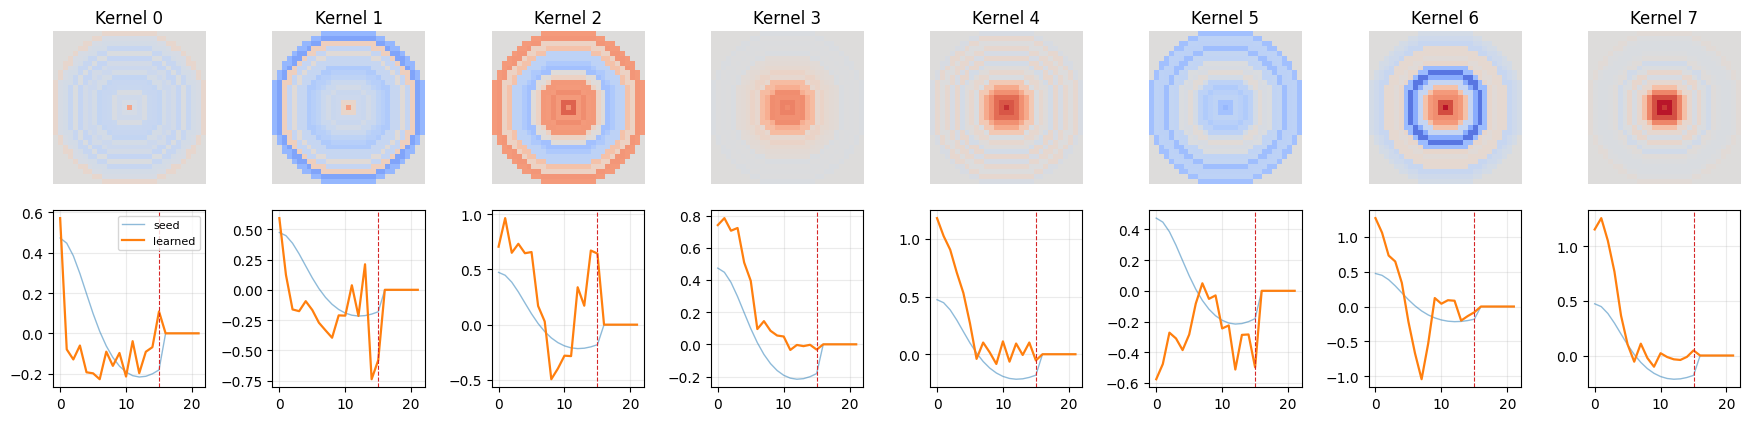

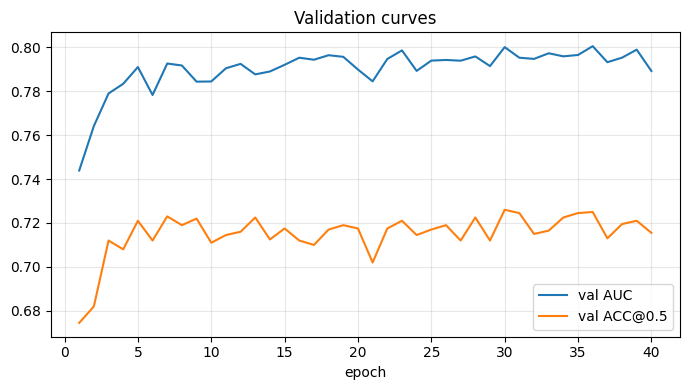

Saved radial-kernel bank artifacts to results/brain2_radial_v4_center_matched


In [38]:
n_show = min(int(NUM_RADIAL_KERNELS), 8)
fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.4))
if n_show == 1:
    axes = np.array(axes).reshape(2, 1)
vmax = max(float(np.max(np.abs(seed_radial_kernel))), float(np.max(np.abs(kernel_best)))) + 1e-12
for k in range(n_show):
    axes[0, k].imshow(kernel_best[k], cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axes[0, k].set_title(f"Kernel {k}")
    axes[0, k].axis("off")
    axes[1, k].plot(np.arange(len(f_seed_full)), f_seed_full, linewidth=1.0, alpha=0.5, label="seed")
    axes[1, k].plot(np.arange(f_best_full.shape[1]), f_best_full[k], linewidth=1.6, label="learned")
    axes[1, k].axvline(learnable_len - 1, color="tab:red", linestyle="--", linewidth=0.8)
    axes[1, k].grid(alpha=0.25)
    if k == 0:
        axes[1, k].legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
hist_epochs = np.array([row["epoch"] for row in history], dtype=int)
ax.plot(hist_epochs, [row["val_auc"] for row in history], label="val AUC")
ax.plot(hist_epochs, [row["val_acc"] for row in history], label="val ACC@0.5")
ax.set_xlabel("epoch")
ax.set_title("Validation curves")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

if SAVE_ARTIFACTS:
    np.save(OUT_DIR / "kernel_seed_radial.npy", seed_radial_kernel.astype(np.float32))
    np.save(OUT_DIR / "kernels_learned_radial_bank.npy", kernel_best.astype(np.float32))
    np.save(OUT_DIR / "f_seed_full.npy", f_seed_full.astype(np.float32))
    np.save(OUT_DIR / "f_learned_full_bank.npy", f_best_full.astype(np.float32))
    summary = {
        "config": {
            "dataset_root": str(DATASET_ROOT),
            "patch_output_root": str(PATCH_OUTPUT_ROOT),
            "kernel_size": KERNEL_SIZE,
            "learned_radius_max": LEARNED_RADIUS_MAX,
            "num_radial_kernels": int(NUM_RADIAL_KERNELS),
            "feature_pool_size": int(FEATURE_POOL_SIZE),
            "feature_mode": FEATURE_MODE,
            "response_mode": RESPONSE_MODE,
            "response_feature_names": list(RESPONSE_FEATURE_NAMES),
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
        },
        "seed_profile": [float(x) for x in f_seed_full],
        "learned_profiles": [[float(x) for x in row] for row in f_best_full],
        "metrics": results,
        "history": history,
    }
    (OUT_DIR / "radial_kernel_bank_summary.json").write_text(json.dumps(summary, indent=2))
    print(f"Saved radial-kernel bank artifacts to {OUT_DIR}")


Rendering 6 heatmap examples


Exact heatmap rows: 100%|██████████| 57/57 [00:00<00:00, 536.07it/s]


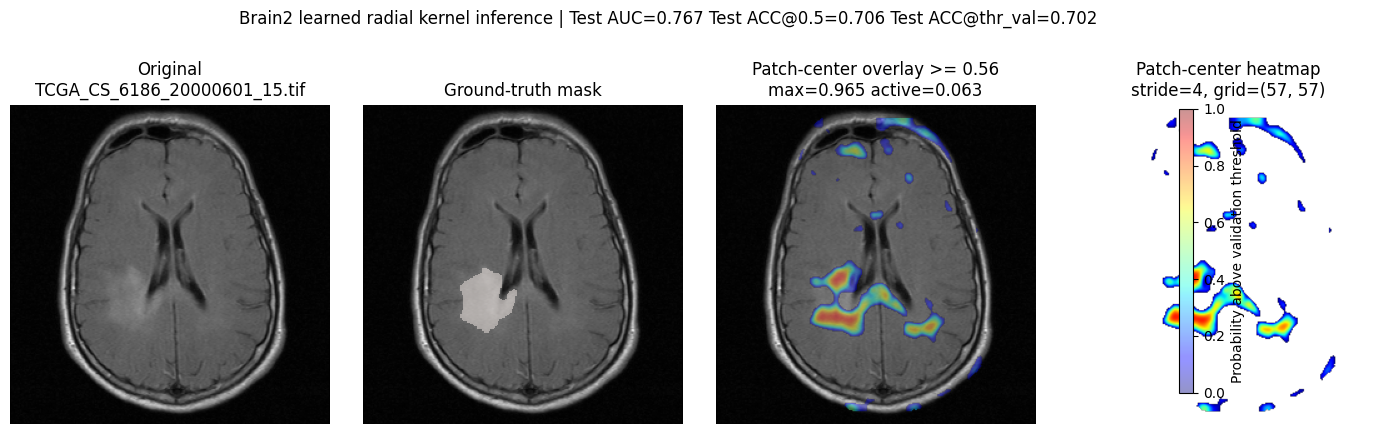

Patch-center heatmap raw probability: max=0.965085 mean=0.320834 active_frac=0.063034 grid=(57, 57)


Exact heatmap rows: 100%|██████████| 57/57 [00:00<00:00, 485.97it/s]


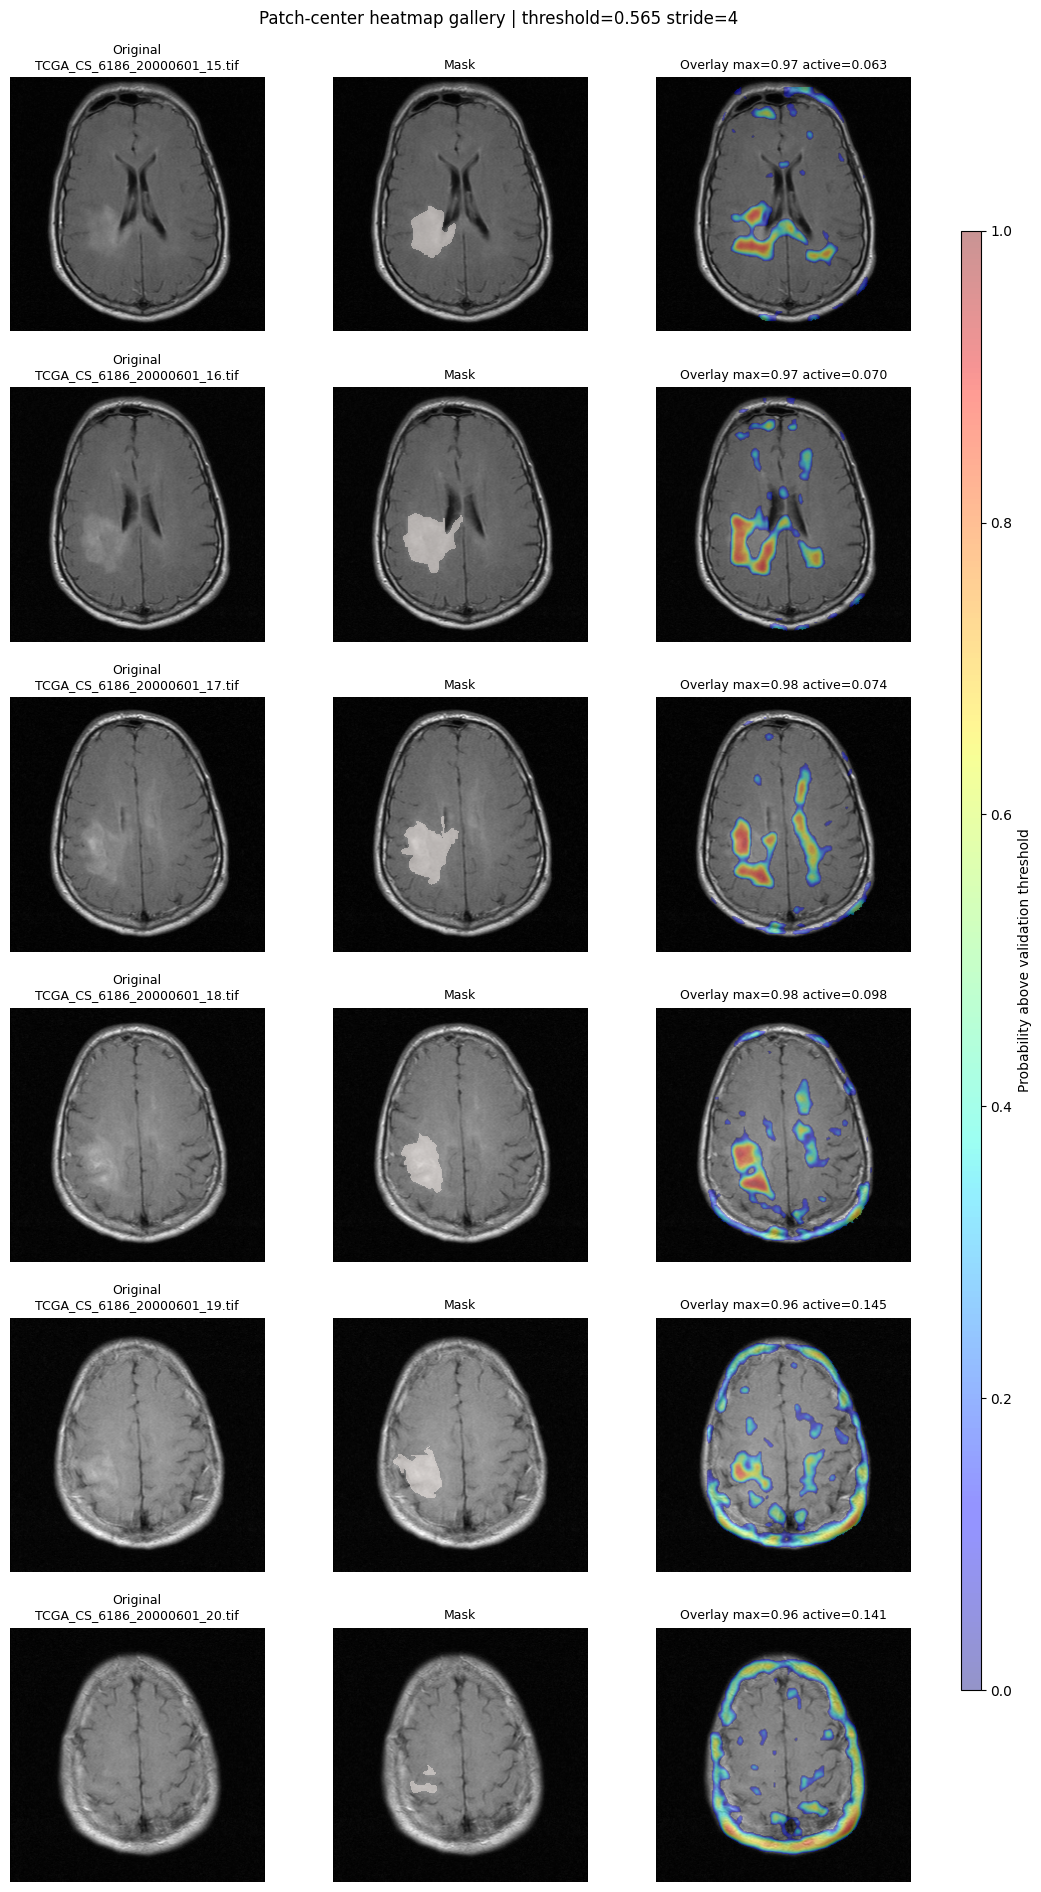

Saved heatmap gallery and first-example maps to results/brain2_radial_v4_center_matched


In [39]:
def find_example_pair(example_path=None):
    pairs = list_image_mask_pairs(DATASET_ROOT)
    if example_path is not None:
        p = Path(example_path)
        if p.is_file():
            mask = p.with_name(f"{p.stem}_mask.tif")
            if not mask.exists() and p.name.endswith("_mask.tif"):
                raise ValueError("EXAMPLE_IMAGE_PATH should point to an image .tif, not a mask .tif")
            if not mask.exists():
                raise FileNotFoundError(f"Mask not found for {p}: expected {mask}")
            return {"patient": p.parent.name, "image": p, "mask": mask, "stem": p.stem}

    split_by_patient = split_patients(pairs, TRAIN_FRAC, VAL_FRAC, SPLIT_SEED)
    preferred = []
    for split in ("test", "val", "train"):
        preferred.extend([row for row in pairs if split_by_patient[row["patient"]] == split])
    for row in preferred:
        mask = mask_to_bool(row["mask"])
        if mask.any():
            return row
    return preferred[0]


def heatmap_response_features(x_t: torch.Tensor, kernel_np: np.ndarray, batch_size: int):
    kernel_t = torch.from_numpy(kernel_np.astype(np.float32)).to(DEVICE)
    if kernel_t.ndim == 2:
        return extract_response_features(x_t, kernel_t, batch_size=batch_size)
    if kernel_t.ndim == 3:
        return extract_bank_features(x_t, kernel_t, batch_size=batch_size)
    raise ValueError(f"Expected 2D kernel or 3D kernel bank, got shape={tuple(kernel_t.shape)}")


def exact_patch_probability_map(img_arr: np.ndarray, kernel_np: np.ndarray, stride: int = 4, batch_size: int = 256):
    """Evaluate the same patch classifier used in training and assign scores to patch centers."""
    h, w = img_arr.shape
    patch_size = int(RESIZE_PATCH)
    stride = int(stride)
    if h < patch_size or w < patch_size:
        raise ValueError(f"Image {img_arr.shape} is smaller than patch size {patch_size}")

    y0s = list(range(0, h - patch_size + 1, stride))
    x0s = list(range(0, w - patch_size + 1, stride))
    if y0s[-1] != h - patch_size:
        y0s.append(h - patch_size)
    if x0s[-1] != w - patch_size:
        x0s.append(w - patch_size)

    prob_grid = np.zeros((len(y0s), len(x0s)), dtype=np.float32)
    center_sum = np.zeros((h, w), dtype=np.float32)
    center_weight = np.zeros((h, w), dtype=np.float32)
    half = patch_size // 2

    patches = []
    coords = []
    for iy, y0 in enumerate(tqdm(y0s, desc="Exact heatmap rows")):
        for ix, x0 in enumerate(x0s):
            patches.append(img_arr[y0 : y0 + patch_size, x0 : x0 + patch_size].astype(np.float32))
            coords.append((iy, ix, min(h - 1, y0 + half), min(w - 1, x0 + half)))
            if len(patches) >= batch_size:
                xb = to_tensor_batch(np.stack(patches, axis=0), torch.device("cpu"))
                if STANDARDIZE_PATCHES:
                    xb = patch_standardize(xb)
                feat = heatmap_response_features(xb, kernel_np, batch_size=batch_size)
                probs = sigmoid_np((feat - calib_mu) / calib_std @ calib_w + calib_b).astype(np.float32)
                for (gy, gx, cy, cx), prob in zip(coords, probs):
                    prob_grid[gy, gx] = float(prob)
                    center_sum[cy, cx] += float(prob)
                    center_weight[cy, cx] += 1.0
                patches.clear()
                coords.clear()

    if patches:
        xb = to_tensor_batch(np.stack(patches, axis=0), torch.device("cpu"))
        if STANDARDIZE_PATCHES:
            xb = patch_standardize(xb)
        feat = heatmap_response_features(xb, kernel_np, batch_size=batch_size)
        probs = sigmoid_np((feat - calib_mu) / calib_std @ calib_w + calib_b).astype(np.float32)
        for (gy, gx, cy, cx), prob in zip(coords, probs):
            prob_grid[gy, gx] = float(prob)
            center_sum[cy, cx] += float(prob)
            center_weight[cy, cx] += 1.0

    # Interpolate sparse center scores without pretending patch top-left positions are pixels.
    sigma = max(1.0, float(stride) / 2.0)
    smooth_sum = gaussian_filter(center_sum, sigma=sigma)
    smooth_weight = gaussian_filter(center_weight, sigma=sigma)
    prob_map = np.divide(smooth_sum, smooth_weight, out=np.zeros_like(smooth_sum), where=smooth_weight > 1e-8)
    valid_center_mask = smooth_weight > (0.01 * float(smooth_weight.max()) if smooth_weight.max() > 0 else 0.0)
    return prob_map.astype(np.float32), prob_grid, valid_center_mask


def prepare_heatmap_display(img_arr: np.ndarray, prob_map: np.ndarray, valid_center_mask: np.ndarray):
    prob_map_vis = gaussian_filter(prob_map, sigma=float(HEATMAP_SMOOTH_SIGMA)) if HEATMAP_SMOOTH_SIGMA > 0 else prob_map
    tissue_display = img_arr > (float(TISSUE_THRESHOLD) / 255.0)
    tissue_display = binary_erosion(tissue_display, iterations=1) if tissue_display.any() else tissue_display
    display_mask = tissue_display & valid_center_mask

    heatmap_threshold = float(results.get("threshold_val", 0.5))
    prob_map_conf = np.clip((prob_map_vis - heatmap_threshold) / max(1e-6, 1.0 - heatmap_threshold), 0.0, 1.0)
    prob_map_display_scaled = prob_map_conf * display_mask.astype(np.float32)
    active_display = display_mask & (prob_map_vis >= heatmap_threshold)

    score_max = float(prob_map[display_mask].max()) if display_mask.any() else float(prob_map.max())
    score_mean = float(prob_map[display_mask].mean()) if display_mask.any() else float(prob_map.mean())
    active_frac = float(active_display.mean())
    return {
        "prob_map_vis": prob_map_vis,
        "prob_map_display_scaled": prob_map_display_scaled,
        "active_display": active_display,
        "display_mask": display_mask,
        "heatmap_threshold": heatmap_threshold,
        "score_max": score_max,
        "score_mean": score_mean,
        "active_frac": active_frac,
    }


def select_heatmap_examples(n_examples: int):
    pairs = list_image_mask_pairs(DATASET_ROOT)
    split_by_patient = split_patients(pairs, TRAIN_FRAC, VAL_FRAC, SPLIT_SEED)
    selected = []

    if EXAMPLE_IMAGE_PATH is not None:
        selected.append(find_example_pair(EXAMPLE_IMAGE_PATH))

    for split in ("test", "val", "train"):
        for row in pairs:
            if len(selected) >= int(n_examples):
                return selected
            if split_by_patient[row["patient"]] != split:
                continue
            if any(row["image"] == prev["image"] for prev in selected):
                continue
            mask = mask_to_bool(row["mask"])
            if mask.any():
                selected.append(row)
    return selected


def compute_heatmap_for_example(example_row):
    img = image_to_gray_float(example_row["image"])
    mask = mask_to_bool(example_row["mask"], shape=img.shape)
    prob_map, prob_grid, valid_center_mask = exact_patch_probability_map(
        img,
        kernel_best,
        stride=EXACT_HEATMAP_STRIDE,
        batch_size=max(BATCH_SIZE, 256),
    )
    display = prepare_heatmap_display(img, prob_map, valid_center_mask)
    return img, mask, prob_map, prob_grid, display


examples = select_heatmap_examples(HEATMAP_N_EXAMPLES)
print(f"Rendering {len(examples)} heatmap examples")

# Detailed view for the first example, same layout as before.
example = examples[0]
example_img, example_mask, prob_map, prob_grid, display = compute_heatmap_for_example(example)
prob_map_display_scaled = display["prob_map_display_scaled"]
active_display = display["active_display"]
score_max = display["score_max"]
score_mean = display["score_mean"]
active_frac = display["active_frac"]
heatmap_threshold = display["heatmap_threshold"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes[0].imshow(example_img, cmap="gray")
axes[0].set_title(f"Original\n{example['image'].name}")
axes[0].axis("off")

axes[1].imshow(example_img, cmap="gray")
axes[1].imshow(np.ma.masked_where(~example_mask, example_mask), cmap="Reds", alpha=0.45, interpolation="nearest")
axes[1].set_title("Ground-truth mask")
axes[1].axis("off")

axes[2].imshow(example_img, cmap="gray")
im = axes[2].imshow(
    np.ma.masked_where(~active_display, prob_map_display_scaled),
    cmap="jet",
    alpha=DENSE_OVERLAY_ALPHA,
    vmin=0.0,
    vmax=1.0,
    interpolation="bilinear",
)
axes[2].set_title(f"Patch-center overlay >= {heatmap_threshold:.2f}\nmax={score_max:.3f} active={active_frac:.3f}")
axes[2].axis("off")

axes[3].imshow(np.ma.masked_where(~active_display, prob_map_display_scaled), cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[3].set_title(f"Patch-center heatmap\nstride={EXACT_HEATMAP_STRIDE}, grid={prob_grid.shape}")
axes[3].axis("off")

fig.suptitle(
    "Brain2 learned radial kernel inference | "
    f"Test AUC={results['test_05']['auc']:.3f} "
    f"Test ACC@0.5={results['test_05']['acc']:.3f} "
    f"Test ACC@thr_val={results['test_tuned']['acc']:.3f}",
    y=1.03,
)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.82)
cbar.set_label("Probability above validation threshold")
fig.subplots_adjust(top=0.82, wspace=0.05)
plt.show()

print(
    f"Patch-center heatmap raw probability: max={score_max:.6f} "
    f"mean={score_mean:.6f} active_frac={active_frac:.6f} grid={prob_grid.shape}"
)

# Gallery view across multiple slices.
gallery_rows = []
for row in examples:
    img, mask, pmap, pgrid, disp = compute_heatmap_for_example(row)
    gallery_rows.append((row, img, mask, pmap, pgrid, disp))

fig, axes = plt.subplots(len(gallery_rows), 3, figsize=(11, 3.2 * len(gallery_rows)))
if len(gallery_rows) == 1:
    axes = np.array([axes])
last_im = None
for r, (row, img, mask, pmap, pgrid, disp) in enumerate(gallery_rows):
    overlay = disp["prob_map_display_scaled"]
    active = disp["active_display"]
    axes[r, 0].imshow(img, cmap="gray")
    axes[r, 0].set_title(f"Original\n{row['image'].name}", fontsize=9)
    axes[r, 0].axis("off")

    axes[r, 1].imshow(img, cmap="gray")
    axes[r, 1].imshow(np.ma.masked_where(~mask, mask), cmap="Reds", alpha=0.45, interpolation="nearest")
    axes[r, 1].set_title("Mask", fontsize=9)
    axes[r, 1].axis("off")

    axes[r, 2].imshow(img, cmap="gray")
    last_im = axes[r, 2].imshow(
        np.ma.masked_where(~active, overlay),
        cmap="jet",
        alpha=DENSE_OVERLAY_ALPHA,
        vmin=0.0,
        vmax=1.0,
        interpolation="bilinear",
    )
    axes[r, 2].set_title(
        f"Overlay max={disp['score_max']:.2f} active={disp['active_frac']:.3f}",
        fontsize=9,
    )
    axes[r, 2].axis("off")

fig.suptitle(
    f"Patch-center heatmap gallery | threshold={float(results.get('threshold_val', 0.5)):.3f} "
    f"stride={EXACT_HEATMAP_STRIDE}",
    y=0.995,
)
fig.subplots_adjust(left=0.03, right=0.90, top=0.96, bottom=0.02, wspace=0.04, hspace=0.22)
if last_im is not None:
    cax = fig.add_axes([0.92, 0.12, 0.018, 0.76])
    fig.colorbar(last_im, cax=cax, label="Probability above validation threshold")
plt.show()

if SAVE_ARTIFACTS:
    np.save(OUT_DIR / f"{example['stem']}_learned_radial_prob_map.npy", prob_map.astype(np.float32))
    np.save(OUT_DIR / f"{example['stem']}_learned_radial_prob_grid.npy", prob_grid.astype(np.float32))
    fig.savefig(OUT_DIR / "heatmap_gallery.png", dpi=260, bbox_inches="tight")
    print(f"Saved heatmap gallery and first-example maps to {OUT_DIR}")


# Merge redundant kernels → minimal set of distinct kernels

After training the `NUM_RADIAL_KERNELS`-kernel bank, several profiles often end up
responding almost identically (or as sign-flipped copies) to the data. Those are
redundant: the classifier gains nothing from keeping both.

**Method**
1. **Similarity in response space.** For each kernel we take its convolution response
   over a subsample of training patches and compute the Pearson correlation between
   kernels. Redundancy is measured as `|corr|`, so a kernel and its sign-flipped twin
   count as the same. Response correlation (not raw kernel cosine) is used because the
   classifier only ever sees responses — this is the quantity tied to "no loss of quality."
2. **Hierarchical clustering** on distance `1 - |corr|` with average linkage.
3. **Merge** each cluster into one radial profile: members are sign-aligned to the
   cluster medoid, averaged, then renormalized to the members' mean norm. The merged
   profile is re-expanded through the radial basis, so the result stays a valid radial kernel.
4. **Sweep** every achievable cluster count `K' = K … 1`, refit the same balanced
   logistic head on each reduced bank, and pick the **smallest** `K'` whose validation
   AUC and tuned validation accuracy stay within `MERGE_QUALITY_TOL` of the full bank.

Response correlation for 16 kernels from 614,400 response samples
|corr| off-diagonal: min=0.003 mean=0.500 max=0.991


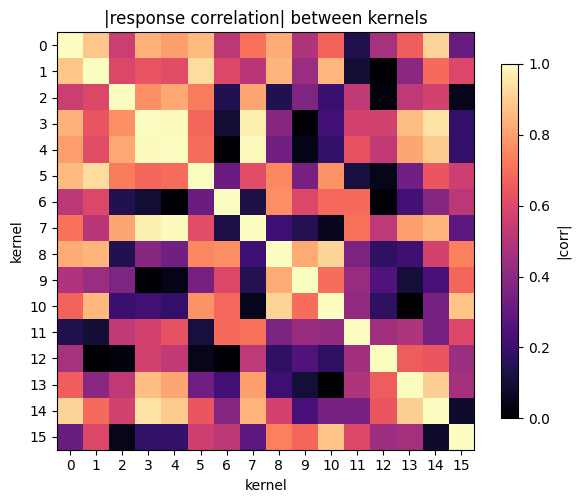

In [40]:
# =====================================================================
# Kernel de-duplication (1/3): response-correlation similarity matrix.
#
# Redundancy is measured in RESPONSE space: two kernels are redundant if
# they respond the same way to the actual training patches, up to sign.
# =====================================================================
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

MERGE_MAX_PATCHES = 600      # training patches used to estimate response correlation
MERGE_QUALITY_TOL = 0.005    # allowed drop in val AUC / tuned val ACC vs full bank


@torch.no_grad()
def kernel_response_matrix(x_t, kernels_t, max_patches=MERGE_MAX_PATCHES, batch_size=BATCH_SIZE):
    """[K, N*H*W] flattened conv responses over a deterministic patch subsample."""
    n_total = x_t.shape[0]
    n = min(int(max_patches), n_total)
    idx = np.linspace(0, n_total - 1, n).astype(np.int64)
    kt = kernels_t.to(DEVICE)
    chunks = []
    for i in range(0, n, batch_size):
        xb = x_t[idx[i:i + batch_size]].to(DEVICE, non_blocking=True)
        conv = F.conv2d(xb, kt[:, None], padding=kt.shape[-1] // 2)      # [B, K, H, W]
        chunks.append(conv.permute(1, 0, 2, 3).reshape(kt.shape[0], -1).cpu().numpy())
    return np.concatenate(chunks, axis=1).astype(np.float32)


resp_mat = kernel_response_matrix(X_train_t, kernels_best_t)
corr = np.nan_to_num(np.corrcoef(resp_mat), nan=0.0)     # [K, K] signed response correlation
abs_corr = np.abs(corr)
np.fill_diagonal(abs_corr, 1.0)

K0 = corr.shape[0]
offdiag = abs_corr[np.triu_indices(K0, k=1)]
print(f"Response correlation for {K0} kernels from {resp_mat.shape[1]:,} response samples")
print(f"|corr| off-diagonal: min={offdiag.min():.3f} mean={offdiag.mean():.3f} max={offdiag.max():.3f}")

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.imshow(abs_corr, cmap="magma", vmin=0.0, vmax=1.0)
ax.set_title("|response correlation| between kernels")
ax.set_xlabel("kernel"); ax.set_ylabel("kernel")
ax.set_xticks(range(K0)); ax.set_yticks(range(K0))
fig.colorbar(im, ax=ax, shrink=0.85, label="|corr|")
plt.tight_layout(); plt.show()

Full bank (K=16): val_auc=0.7757 val_acc_tuned=0.7145 test_auc=0.7670 test_acc_tuned=0.7015

K'=16 | val_auc=0.7756 val_acc_tuned=0.7145 test_auc=0.7670 test_acc_tuned=0.7020
K'=15 | val_auc=0.7754 val_acc_tuned=0.7175 test_auc=0.7662 test_acc_tuned=0.6930
K'=14 | val_auc=0.7747 val_acc_tuned=0.7160 test_auc=0.7650 test_acc_tuned=0.6860
K'=13 | val_auc=0.7717 val_acc_tuned=0.7145 test_auc=0.7650 test_acc_tuned=0.6945
K'=12 | val_auc=0.7705 val_acc_tuned=0.7090 test_auc=0.7642 test_acc_tuned=0.7005
K'=11 | val_auc=0.7698 val_acc_tuned=0.7085 test_auc=0.7628 test_acc_tuned=0.6820
K'=10 | val_auc=0.7581 val_acc_tuned=0.6990 test_auc=0.7530 test_acc_tuned=0.6825
K'= 9 | val_auc=0.7602 val_acc_tuned=0.7030 test_auc=0.7544 test_acc_tuned=0.6830
K'= 8 | val_auc=0.7551 val_acc_tuned=0.6975 test_auc=0.7550 test_acc_tuned=0.6775
K'= 7 | val_auc=0.7528 val_acc_tuned=0.6950 test_auc=0.7566 test_acc_tuned=0.6795
K'= 6 | val_auc=0.7546 val_acc_tuned=0.6955 test_auc=0.7554 test_acc_tuned=0.6795
K'= 5

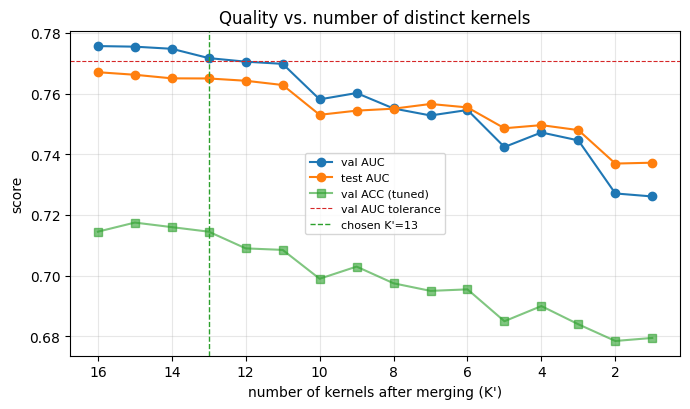

In [41]:
# =====================================================================
# Kernel de-duplication (2/3): cluster, merge, and sweep K' = K..1.
# =====================================================================
def kernels_from_full_profiles(f_full_np):
    """Re-expand full radial profiles [K, R] into radial 2D kernels [K, H, W]."""
    ft = torch.from_numpy(np.asarray(f_full_np, dtype=np.float32)).to(DEVICE)
    return torch.einsum("kr,rhw->khw", ft, basis_t).detach().cpu().numpy().astype(np.float32)


def merge_profiles_by_labels(f_full_np, labels, corr_mat):
    """Merge each cluster into one sign-aligned, norm-matched radial profile."""
    labels = np.asarray(labels)
    merged, groups = [], []
    for lab in sorted(set(labels.tolist())):
        members = np.where(labels == lab)[0].tolist()
        # medoid = member most correlated (abs) with the rest of its cluster
        ref = members[int(np.argmax([np.abs(corr_mat[m, members]).sum() for m in members]))]
        acc = np.zeros(f_full_np.shape[1], dtype=np.float64)
        for m in members:
            sign = 1.0 if corr_mat[ref, m] >= 0 else -1.0
            acc += sign * f_full_np[m]
        acc /= len(members)
        target_norm = float(np.mean([np.linalg.norm(f_full_np[m]) for m in members]))
        nrm = float(np.linalg.norm(acc))
        if nrm > 1e-8:
            acc = acc / nrm * target_norm
        merged.append(acc.astype(np.float32))
        groups.append(members)
    return np.stack(merged, axis=0).astype(np.float32), groups


def evaluate_kernel_bank(kernels_np):
    """Refit the same balanced logistic head on a kernel bank and score it."""
    kt = torch.from_numpy(np.asarray(kernels_np, dtype=np.float32)).to(DEVICE)
    tr = extract_bank_features(X_train_t, kt, BATCH_SIZE)
    va = extract_bank_features(X_val_t, kt, BATCH_SIZE)
    te = extract_bank_features(X_test_t, kt, BATCH_SIZE)
    mu = tr.mean(axis=0); sd = tr.std(axis=0); sd = np.where(sd > 1e-8, sd, 1.0)
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf.fit((tr - mu) / sd, y_train)
    vap = clf.predict_proba((va - mu) / sd)[:, 1]
    tep = clf.predict_proba((te - mu) / sd)[:, 1]
    thr, _ = best_threshold_by_accuracy(y_val, vap, THRESHOLD_GRID_SIZE)
    return {
        "val_auc": metrics_from_probs(y_val, vap, 0.5)["auc"],
        "val_acc": metrics_from_probs(y_val, vap, 0.5)["acc"],
        "val_acc_tuned": metrics_from_probs(y_val, vap, thr)["acc"],
        "test_auc": metrics_from_probs(y_test, tep, 0.5)["auc"],
        "test_acc": metrics_from_probs(y_test, tep, 0.5)["acc"],
        "test_acc_tuned": metrics_from_probs(y_test, tep, thr)["acc"],
        "threshold": float(thr), "clf": clf, "mu": mu, "sd": sd,
    }


# Hierarchical clustering on 1 - |corr| (average linkage).
dist = 1.0 - abs_corr
dist = 0.5 * (dist + dist.T)
np.fill_diagonal(dist, 0.0)
Z = linkage(squareform(dist, checks=False), method="average")

# Baseline = full bank pushed through the exact same refit pipeline.
baseline = evaluate_kernel_bank(kernel_best)
print(f"Full bank (K={K0}): val_auc={baseline['val_auc']:.4f} "
      f"val_acc_tuned={baseline['val_acc_tuned']:.4f} "
      f"test_auc={baseline['test_auc']:.4f} test_acc_tuned={baseline['test_acc_tuned']:.4f}\n")

# Sweep every achievable number of clusters K' = K..1.
sweep, seen_k = [], set()
for target in range(K0, 0, -1):
    labels = fcluster(Z, t=target, criterion="maxclust")
    kp = int(labels.max())
    if kp in seen_k:
        continue
    seen_k.add(kp)
    f_merged, groups = merge_profiles_by_labels(f_best_full, labels, corr)
    ev = evaluate_kernel_bank(kernels_from_full_profiles(f_merged))
    ev.update({"k": kp, "labels": labels, "f_merged": f_merged, "groups": groups})
    sweep.append(ev)
    print(f"K'={kp:2d} | val_auc={ev['val_auc']:.4f} val_acc_tuned={ev['val_acc_tuned']:.4f} "
          f"test_auc={ev['test_auc']:.4f} test_acc_tuned={ev['test_acc_tuned']:.4f}")
sweep.sort(key=lambda d: d["k"])

# Smallest K' whose val AUC and tuned val ACC stay within tolerance of the full bank.
eligible = [s for s in sweep
            if s["val_auc"] >= baseline["val_auc"] - MERGE_QUALITY_TOL
            and s["val_acc_tuned"] >= baseline["val_acc_tuned"] - MERGE_QUALITY_TOL]
chosen = min(eligible, key=lambda d: d["k"]) if eligible else max(sweep, key=lambda d: d["k"])
print(f"\nChosen minimal distinct kernels: K'={chosen['k']} "
      f"(tolerance={MERGE_QUALITY_TOL} on val AUC & tuned val ACC)")

# Quality-vs-count curve.
ks = [s["k"] for s in sweep]
fig, ax = plt.subplots(1, 1, figsize=(7, 4.2))
ax.plot(ks, [s["val_auc"] for s in sweep], "-o", label="val AUC")
ax.plot(ks, [s["test_auc"] for s in sweep], "-o", label="test AUC")
ax.plot(ks, [s["val_acc_tuned"] for s in sweep], "-s", alpha=0.6, label="val ACC (tuned)")
ax.axhline(baseline["val_auc"] - MERGE_QUALITY_TOL, color="tab:red", ls="--", lw=0.8, label="val AUC tolerance")
ax.axvline(chosen["k"], color="tab:green", ls="--", lw=1.0, label=f"chosen K'={chosen['k']}")
ax.set_xlabel("number of kernels after merging (K')"); ax.set_ylabel("score")
ax.set_title("Quality vs. number of distinct kernels")
ax.invert_xaxis(); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Kernel reduction: 16 -> 13 kernels (19% fewer)
------------------------------------------------------------------
metric                   full(16)      reduced(13)     delta
val AUC                    0.7757           0.7717   -0.0040
val ACC*                   0.7145           0.7145   +0.0000
test AUC                   0.7670           0.7650   -0.0021
test ACC*                  0.7015           0.6945   -0.0070
* accuracy at the validation-tuned threshold

Merge groups (original kernel indices -> reduced kernel):
  reduced[0] <- [3, 4, 7]
  reduced[1] <- [0]
  reduced[2] <- [14]
  reduced[3] <- [13]
  reduced[4] <- [2]
  reduced[5] <- [12]
  reduced[6] <- [6]
  reduced[7] <- [11]
  reduced[8] <- [1, 5]
  reduced[9] <- [8]
  reduced[10] <- [10]
  reduced[11] <- [15]
  reduced[12] <- [9]


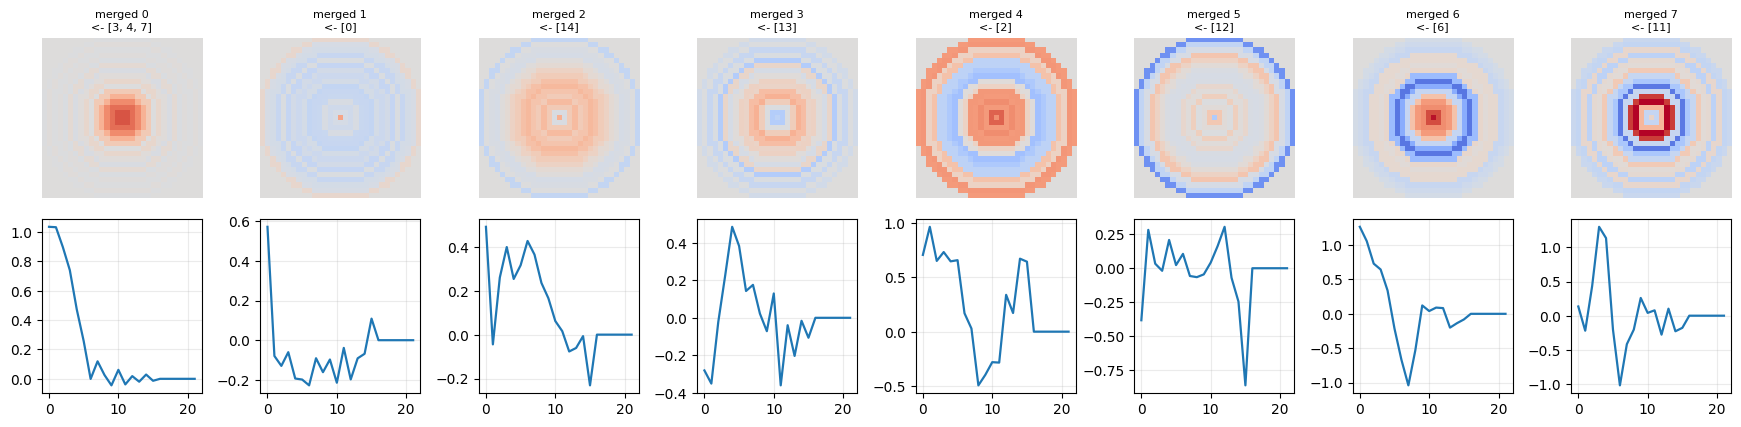


Saved reduced kernel bank (13 kernels) and summary to results/brain2_radial_v4_center_matched


In [42]:
# =====================================================================
# Kernel de-duplication (3/3): finalize reduced bank, compare, save.
# =====================================================================
f_reduced_full = chosen["f_merged"].astype(np.float32)
kernel_reduced = kernels_from_full_profiles(f_reduced_full).astype(np.float32)
reduced_eval = evaluate_kernel_bank(kernel_reduced)

print("=" * 66)
print(f"Kernel reduction: {K0} -> {chosen['k']} kernels "
      f"({100.0 * (1 - chosen['k'] / K0):.0f}% fewer)")
print("-" * 66)
print(f"{'metric':<18}{'full(' + str(K0) + ')':>15}{'reduced(' + str(chosen['k']) + ')':>17}{'delta':>10}")
for key, label in [("val_auc", "val AUC"), ("val_acc_tuned", "val ACC*"),
                   ("test_auc", "test AUC"), ("test_acc_tuned", "test ACC*")]:
    b, r = baseline[key], reduced_eval[key]
    print(f"{label:<18}{b:>15.4f}{r:>17.4f}{r - b:>+10.4f}")
print("* accuracy at the validation-tuned threshold")

print("\nMerge groups (original kernel indices -> reduced kernel):")
for j, members in enumerate(chosen["groups"]):
    print(f"  reduced[{j}] <- {members}")

# Visualize reduced kernels and their radial profiles.
Kp = chosen["k"]
n_show = min(Kp, 8)
fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.4))
if n_show == 1:
    axes = np.array(axes).reshape(2, 1)
vmax = float(np.max(np.abs(kernel_reduced))) + 1e-12
for j in range(n_show):
    axes[0, j].imshow(kernel_reduced[j], cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axes[0, j].set_title(f"merged {j}\n<- {chosen['groups'][j]}", fontsize=8)
    axes[0, j].axis("off")
    axes[1, j].plot(np.arange(f_reduced_full.shape[1]), f_reduced_full[j], lw=1.6)
    axes[1, j].grid(alpha=0.25)
plt.tight_layout(); plt.show()

if SAVE_ARTIFACTS:
    np.save(OUT_DIR / "kernels_reduced_radial_bank.npy", kernel_reduced)
    np.save(OUT_DIR / "f_reduced_full_bank.npy", f_reduced_full)
    reduce_summary = {
        "num_kernels_full": int(K0),
        "num_kernels_reduced": int(Kp),
        "quality_tolerance": float(MERGE_QUALITY_TOL),
        "similarity": "abs_response_correlation",
        "linkage": "average",
        "baseline_metrics": {k: float(baseline[k]) for k in
                             ("val_auc", "val_acc", "val_acc_tuned", "test_auc", "test_acc", "test_acc_tuned")},
        "reduced_metrics": {k: float(reduced_eval[k]) for k in
                            ("val_auc", "val_acc", "val_acc_tuned", "test_auc", "test_acc", "test_acc_tuned")},
        "merge_groups": [[int(m) for m in g] for g in chosen["groups"]],
        "sweep": [{"k": int(s["k"]), "val_auc": float(s["val_auc"]),
                   "val_acc_tuned": float(s["val_acc_tuned"]),
                   "test_auc": float(s["test_auc"]),
                   "test_acc_tuned": float(s["test_acc_tuned"])} for s in sweep],
    }
    (OUT_DIR / "kernel_reduction_summary.json").write_text(json.dumps(reduce_summary, indent=2))
    print(f"\nSaved reduced kernel bank ({Kp} kernels) and summary to {OUT_DIR}")

Rendering 6 reduced-bank heatmap examples (K'=13)


Exact heatmap rows: 100%|██████████| 57/57 [00:00<00:00, 495.61it/s]


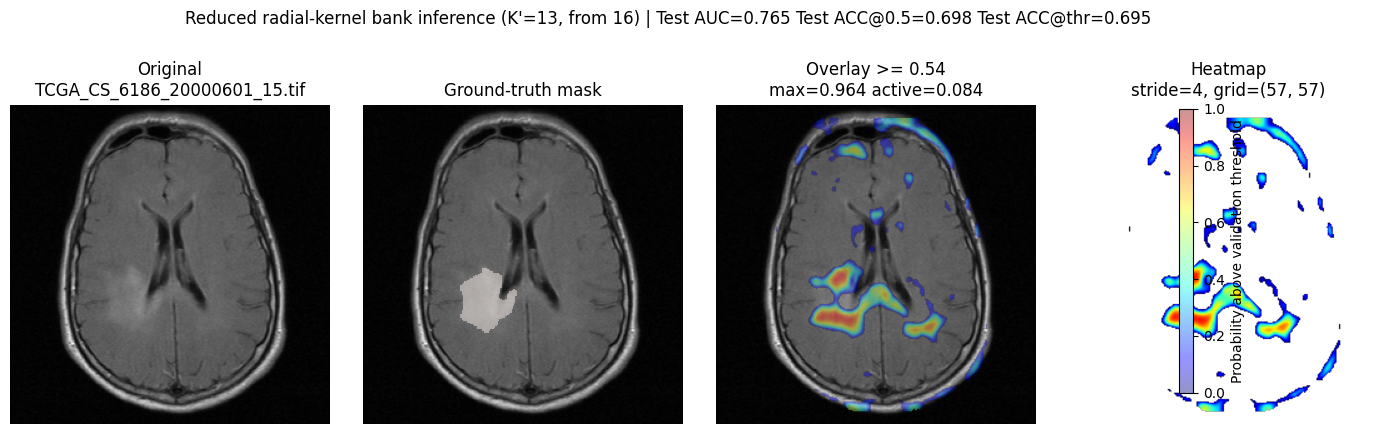

Exact heatmap rows: 100%|██████████| 57/57 [00:00<00:00, 418.71it/s]


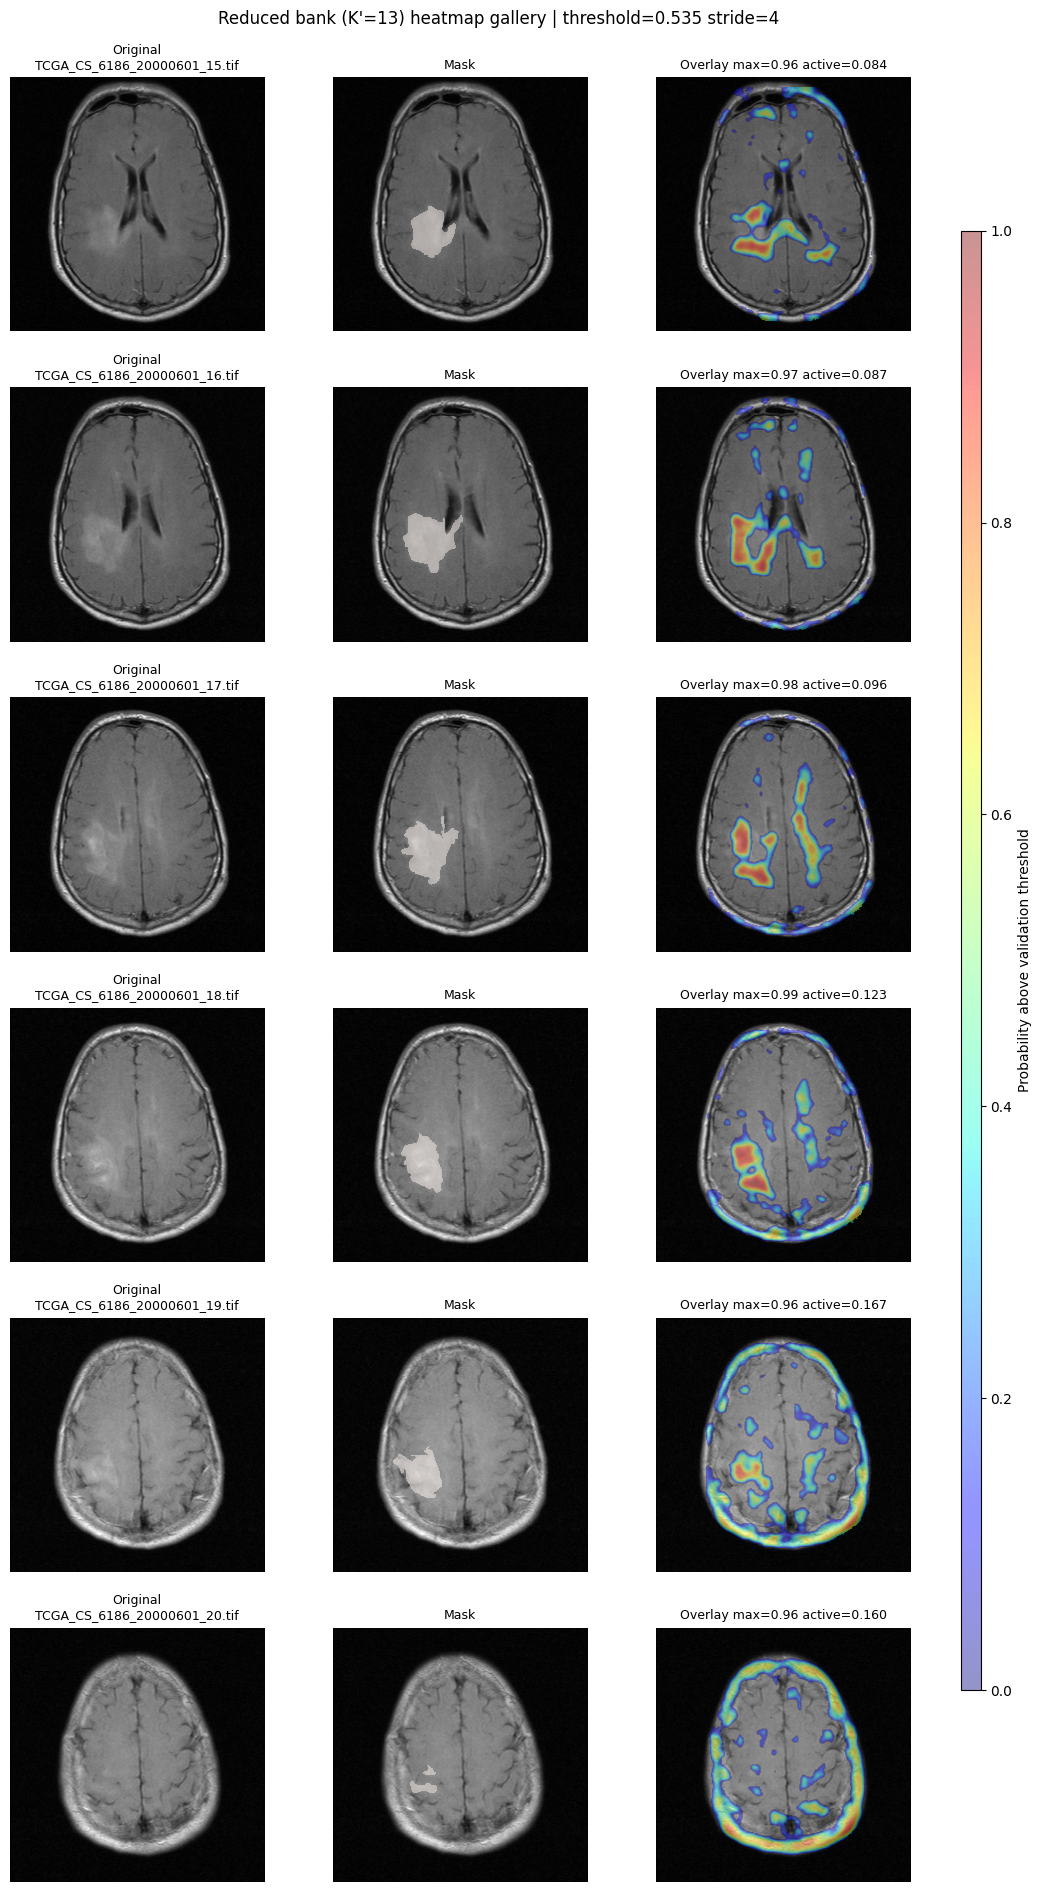

Saved reduced-bank heatmap gallery and first-example maps to results/brain2_radial_v4_center_matched
Restored full-bank calibration globals.


In [43]:
# =====================================================================
# Inference visualization for the REDUCED kernel bank.
#
# Reuses the same heatmap pipeline as the full bank, but scores patches
# with the reduced kernels + their refit logistic head. The calibration
# globals are swapped in temporarily and restored afterwards, so the
# full-bank state above is left untouched.
# =====================================================================
_reduced_clf = reduced_eval["clf"]
_calib_backup = (calib_mu, calib_std, calib_w, calib_b, results.get("threshold_val", 0.5))
calib_mu = reduced_eval["mu"].astype(np.float32)
calib_std = reduced_eval["sd"].astype(np.float32)
calib_w = _reduced_clf.coef_[0].astype(np.float32)
calib_b = float(_reduced_clf.intercept_[0])
results["threshold_val"] = float(reduced_eval["threshold"])


def compute_heatmap_reduced(example_row):
    img = image_to_gray_float(example_row["image"])
    mask = mask_to_bool(example_row["mask"], shape=img.shape)
    prob_map, prob_grid, valid = exact_patch_probability_map(
        img, kernel_reduced, stride=EXACT_HEATMAP_STRIDE, batch_size=max(BATCH_SIZE, 256))
    display = prepare_heatmap_display(img, prob_map, valid)
    return img, mask, prob_map, prob_grid, display


try:
    examples_reduced = select_heatmap_examples(HEATMAP_N_EXAMPLES)
    print(f"Rendering {len(examples_reduced)} reduced-bank heatmap examples (K'={chosen['k']})")

    # Detailed 4-panel view for the first example.
    ex0 = examples_reduced[0]
    img0, mask0, pmap0, pgrid0, disp0 = compute_heatmap_reduced(ex0)
    thr0 = disp0["heatmap_threshold"]
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    axes[0].imshow(img0, cmap="gray")
    axes[0].set_title(f"Original\n{ex0['image'].name}"); axes[0].axis("off")
    axes[1].imshow(img0, cmap="gray")
    axes[1].imshow(np.ma.masked_where(~mask0, mask0), cmap="Reds", alpha=0.45, interpolation="nearest")
    axes[1].set_title("Ground-truth mask"); axes[1].axis("off")
    axes[2].imshow(img0, cmap="gray")
    im = axes[2].imshow(np.ma.masked_where(~disp0["active_display"], disp0["prob_map_display_scaled"]),
                        cmap="jet", alpha=DENSE_OVERLAY_ALPHA, vmin=0.0, vmax=1.0, interpolation="bilinear")
    axes[2].set_title(f"Overlay >= {thr0:.2f}\nmax={disp0['score_max']:.3f} active={disp0['active_frac']:.3f}")
    axes[2].axis("off")
    axes[3].imshow(np.ma.masked_where(~disp0["active_display"], disp0["prob_map_display_scaled"]),
                   cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
    axes[3].set_title(f"Heatmap\nstride={EXACT_HEATMAP_STRIDE}, grid={pgrid0.shape}"); axes[3].axis("off")
    fig.suptitle(
        f"Reduced radial-kernel bank inference (K'={chosen['k']}, from {K0}) | "
        f"Test AUC={reduced_eval['test_auc']:.3f} "
        f"Test ACC@0.5={reduced_eval['test_acc']:.3f} "
        f"Test ACC@thr={reduced_eval['test_acc_tuned']:.3f}", y=1.03)
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.82)
    cbar.set_label("Probability above validation threshold")
    fig.subplots_adjust(top=0.82, wspace=0.05)
    plt.show()

    # Gallery view across multiple slices.
    gallery = [(row,) + compute_heatmap_reduced(row) for row in examples_reduced]
    fig, axes = plt.subplots(len(gallery), 3, figsize=(11, 3.2 * len(gallery)))
    if len(gallery) == 1:
        axes = np.array([axes])
    last_im = None
    for r, (row, img, mask, pmap, pgrid, disp) in enumerate(gallery):
        axes[r, 0].imshow(img, cmap="gray")
        axes[r, 0].set_title(f"Original\n{row['image'].name}", fontsize=9); axes[r, 0].axis("off")
        axes[r, 1].imshow(img, cmap="gray")
        axes[r, 1].imshow(np.ma.masked_where(~mask, mask), cmap="Reds", alpha=0.45, interpolation="nearest")
        axes[r, 1].set_title("Mask", fontsize=9); axes[r, 1].axis("off")
        axes[r, 2].imshow(img, cmap="gray")
        last_im = axes[r, 2].imshow(np.ma.masked_where(~disp["active_display"], disp["prob_map_display_scaled"]),
                                    cmap="jet", alpha=DENSE_OVERLAY_ALPHA, vmin=0.0, vmax=1.0, interpolation="bilinear")
        axes[r, 2].set_title(f"Overlay max={disp['score_max']:.2f} active={disp['active_frac']:.3f}", fontsize=9)
        axes[r, 2].axis("off")
    fig.suptitle(
        f"Reduced bank (K'={chosen['k']}) heatmap gallery | "
        f"threshold={float(results['threshold_val']):.3f} stride={EXACT_HEATMAP_STRIDE}", y=0.995)
    fig.subplots_adjust(left=0.03, right=0.90, top=0.96, bottom=0.02, wspace=0.04, hspace=0.22)
    if last_im is not None:
        cax = fig.add_axes([0.92, 0.12, 0.018, 0.76])
        fig.colorbar(last_im, cax=cax, label="Probability above validation threshold")
    plt.show()

    if SAVE_ARTIFACTS:
        fig.savefig(OUT_DIR / "heatmap_gallery_reduced.png", dpi=260, bbox_inches="tight")
        np.save(OUT_DIR / f"{ex0['stem']}_reduced_prob_map.npy", pmap0.astype(np.float32))
        np.save(OUT_DIR / f"{ex0['stem']}_reduced_prob_grid.npy", pgrid0.astype(np.float32))
        print(f"Saved reduced-bank heatmap gallery and first-example maps to {OUT_DIR}")
finally:
    calib_mu, calib_std, calib_w, calib_b, results["threshold_val"] = _calib_backup
    print("Restored full-bank calibration globals.")


## Inference-only localization refinement (occlusion attribution)

This section does **not** retrain the classifier. It first finds suspicious 64×64 windows with the existing model, then asks which small regions inside each window actually support its tumor probability. Overlapping positive occlusion contributions are averaged into a fine map. The spatial threshold is selected only from validation-patient masks by Dice, rather than reusing the patch-classification threshold.

Important: this can reveal what the classifier uses, but it cannot force a shortcut-learning classifier to attend to tumor. If the refined map consistently highlights normal anatomy, retraining with better-matched negatives is required.

In [44]:
# ---------------- Inference-only localization configuration ----------------
OCCLUSION_BLOCK = 8             # smaller gives finer attribution but costs more
OCCLUSION_BATCH_SIZE = 256
OCCLUSION_MAX_WINDOWS = 160     # highest-scoring windows analyzed per slice
OCCLUSION_WINDOW_PERCENTILE = 90.0
OCCLUSION_MIN_PATCH_PROB = None # None uses the patch validation threshold
OCCLUSION_SMOOTH_SIGMA = 2.0
OCCLUSION_VAL_SLICES = 6        # positive-mask validation slices for Dice tuning
OCCLUSION_KEEP_LARGEST = False  # use True only if one lesion/component is expected
OCCLUSION_SAVE_ARTIFACTS = True

from scipy.ndimage import binary_closing, binary_fill_holes, label as cc_label

def calibrated_patch_probabilities(patches_np, kernel_np, batch_size=256):
    """Run exactly the trained feature extractor and calibration on N grayscale patches."""
    if len(patches_np) == 0:
        return np.empty(0, dtype=np.float32)
    xb = to_tensor_batch(np.asarray(patches_np, dtype=np.float32), torch.device("cpu"))
    if STANDARDIZE_PATCHES:
        xb = patch_standardize(xb)
    feat = heatmap_response_features(xb, kernel_np, batch_size=batch_size)
    return sigmoid_np((feat - calib_mu) / calib_std @ calib_w + calib_b).astype(np.float32)


def intracranial_display_mask(img_arr):
    """Conservative foreground mask; it removes black borders but does not use tumor labels."""
    mask = img_arr > (float(TISSUE_THRESHOLD) / 255.0)
    if mask.any():
        mask = binary_closing(mask, iterations=2)
        mask = binary_fill_holes(mask)
        labs, nlab = cc_label(mask)
        if nlab:
            sizes = np.bincount(labs.ravel()); sizes[0] = 0
            mask = labs == int(np.argmax(sizes))
        mask = binary_erosion(mask, iterations=1)
    return mask.astype(bool)


def occlusion_localization_map(img_arr, kernel_np, stride=EXACT_HEATMAP_STRIDE,
                               block=OCCLUSION_BLOCK, max_windows=OCCLUSION_MAX_WINDOWS,
                               batch_size=OCCLUSION_BATCH_SIZE):
    """Aggregate positive probability drops from mean-occluding small blocks.

    Only the strongest coarse windows are refined. A positive drop means that the
    removed region supported the tumor prediction; negative drops are not displayed.
    """
    coarse_map, coarse_grid, _ = exact_patch_probability_map(
        img_arr, kernel_np, stride=int(stride), batch_size=int(batch_size))
    h, w = img_arr.shape; ps = int(RESIZE_PATCH); stride = int(stride); block = int(block)
    y0s = list(range(0, h - ps + 1, stride)); x0s = list(range(0, w - ps + 1, stride))
    if y0s[-1] != h - ps: y0s.append(h - ps)
    if x0s[-1] != w - ps: x0s.append(w - ps)
    tissue = intracranial_display_mask(img_arr)
    center_ok = np.array([[tissue[min(h-1, y+ps//2), min(w-1, x+ps//2)]
                           for x in x0s] for y in y0s], dtype=bool)
    eligible = coarse_grid[center_ok]
    patch_thr = float(results.get("threshold_val", 0.5) if OCCLUSION_MIN_PATCH_PROB is None
                      else OCCLUSION_MIN_PATCH_PROB)
    percentile_thr = float(np.percentile(eligible, OCCLUSION_WINDOW_PERCENTILE)) if eligible.size else 1.0
    selection_thr = max(patch_thr, percentile_thr)
    candidates = np.argwhere(center_ok & (coarse_grid >= selection_thr))
    if len(candidates) == 0 and eligible.size:
        candidates = np.argwhere(center_ok & (coarse_grid >= percentile_thr))
    if len(candidates) > int(max_windows):
        scores = coarse_grid[candidates[:, 0], candidates[:, 1]]
        candidates = candidates[np.argsort(scores)[-int(max_windows):]]

    attr_sum = np.zeros((h, w), dtype=np.float32)
    attr_weight = np.zeros((h, w), dtype=np.float32)
    variants, metadata = [], []
    def flush():
        if not variants: return
        probs = calibrated_patch_probabilities(np.stack(variants), kernel_np, batch_size)
        for (y0, x0, by, bx, bh, bw, base_prob), prob in zip(metadata, probs):
            contribution = max(0.0, float(base_prob) - float(prob))
            attr_sum[y0+by:y0+by+bh, x0+bx:x0+bx+bw] += contribution
            attr_weight[y0+by:y0+by+bh, x0+bx:x0+bx+bw] += 1.0
        variants.clear(); metadata.clear()

    for gy, gx in tqdm(candidates, desc="Occlusion-refining windows"):
        y0, x0 = y0s[int(gy)], x0s[int(gx)]
        patch = img_arr[y0:y0+ps, x0:x0+ps].astype(np.float32)
        base_prob = float(coarse_grid[int(gy), int(gx)])
        fill_value = float(patch.mean()) # neutral after per-patch standardization
        for by in range(0, ps, block):
            for bx in range(0, ps, block):
                bh, bw = min(block, ps-by), min(block, ps-bx)
                occluded = patch.copy(); occluded[by:by+bh, bx:bx+bw] = fill_value
                variants.append(occluded)
                metadata.append((y0, x0, by, bx, bh, bw, base_prob))
                if len(variants) >= int(batch_size): flush()
    flush()
    attribution = np.divide(attr_sum, attr_weight, out=np.zeros_like(attr_sum), where=attr_weight > 0)
    if OCCLUSION_SMOOTH_SIGMA > 0:
        attribution = gaussian_filter(attribution, sigma=float(OCCLUSION_SMOOTH_SIGMA))
    attribution *= tissue.astype(np.float32)
    positive = attribution[tissue & (attribution > 0)]
    scale = float(np.percentile(positive, 99.0)) if positive.size else 1.0
    attribution_norm = np.clip(attribution / max(scale, 1e-8), 0.0, 1.0).astype(np.float32)
    info = {"selection_threshold": selection_thr, "n_windows": int(len(candidates)),
            "coarse_max": float(coarse_grid.max()), "scale_p99": scale}
    return attribution_norm, coarse_map, coarse_grid, tissue, info


def best_spatial_threshold_by_dice(maps, masks, brain_masks, n_thresholds=99):
    """Choose one threshold using validation masks only; computes macro slice Dice."""
    thresholds = np.linspace(0.01, 0.99, int(n_thresholds))
    best_thr, best_dice = 0.5, -1.0
    for thr in thresholds:
        dices = []
        for score, truth, brain in zip(maps, masks, brain_masks):
            pred = (score >= thr) & brain
            denom = int(pred.sum()) + int(truth.sum())
            dices.append(1.0 if denom == 0 else 2.0 * float((pred & truth).sum()) / denom)
        mean_dice = float(np.mean(dices))
        if mean_dice > best_dice: best_thr, best_dice = float(thr), mean_dice
    return best_thr, best_dice


def clean_localization(score, brain, threshold, keep_largest=False):
    pred = binary_closing((score >= float(threshold)) & brain, iterations=1)
    labs, nlab = cc_label(pred)
    if nlab:
        sizes = np.bincount(labs.ravel()); sizes[0] = 0
        pred &= np.isin(labs, np.flatnonzero(sizes >= max(8, OCCLUSION_BLOCK**2 // 2)))
        if keep_largest and pred.any():
            labs, _ = cc_label(pred); sizes = np.bincount(labs.ravel()); sizes[0] = 0
            pred = labs == int(np.argmax(sizes))
    return pred.astype(bool)


Occlusion-refining windows: 100%|██████████| 160/160 [00:00<00:00, 1198.02it/s]


validation TCGA_CS_5396_20010302_12: refined 160 windows


Occlusion-refining windows: 100%|██████████| 160/160 [00:00<00:00, 1427.46it/s]


validation TCGA_CS_5396_20010302_13: refined 160 windows


Occlusion-refining windows: 100%|██████████| 160/160 [00:00<00:00, 1453.03it/s]


...

Occlusion-refining windows: 100%|██████████| 160/160 [00:00<00:00, 1464.88it/s]


validation TCGA_CS_5396_20010302_16: refined 160 windows


Occlusion-refining windows: 100%|██████████| 160/160 [00:00<00:00, 1510.23it/s]


validation TCGA_CS_5396_20010302_17: refined 160 windows
Validation-selected spatial threshold=0.040, macro Dice=0.334


Occlusion-refining windows: 100%|██████████| 160/160 [00:00<00:00, 1336.00it/s]


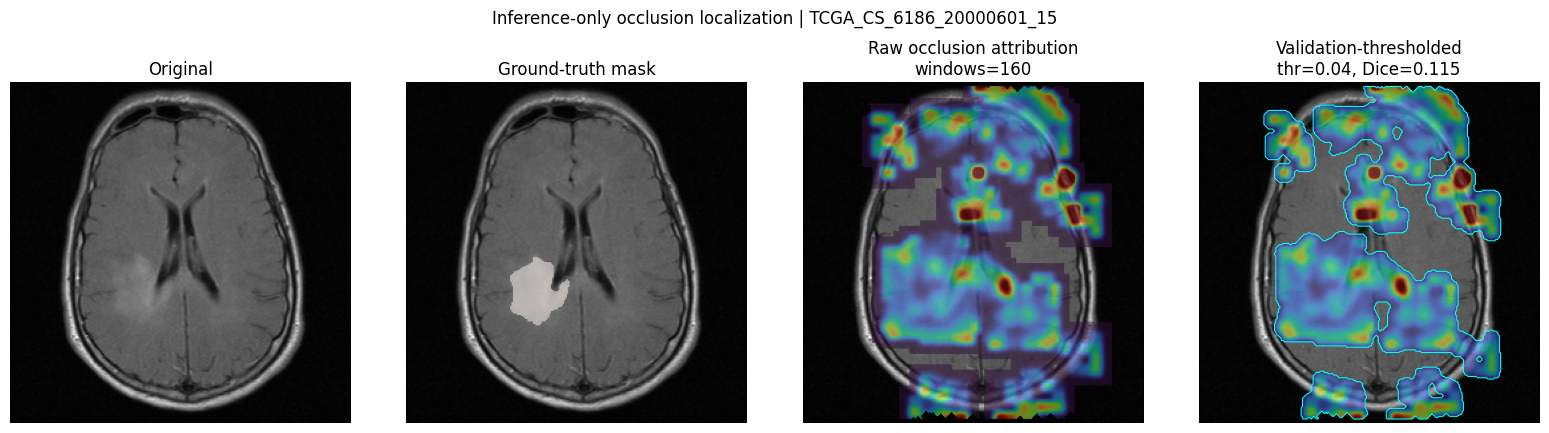

Saved inference-only localization artifacts to results/brain2_radial_v4_center_matched


In [45]:
# ---------------- Tune on validation masks, then render one held-out example ----------------
# This uses the full learned bank and its restored full-bank calibration globals.
localization_kernel = np.asarray(kernel_best, dtype=np.float32)
pairs_all = list_image_mask_pairs(DATASET_ROOT)
split_lookup = split_patients(pairs_all, TRAIN_FRAC, VAL_FRAC, SPLIT_SEED)
val_rows = [r for r in pairs_all if split_lookup[r["patient"]] == "val" and mask_to_bool(r["mask"]).any()]
val_rows = val_rows[:int(OCCLUSION_VAL_SLICES)]
if not val_rows:
    raise RuntimeError("No positive-mask validation slices found for spatial threshold tuning.")

val_attr, val_masks, val_brains = [], [], []
for row in val_rows:
    img_v = image_to_gray_float(row["image"])
    mask_v = mask_to_bool(row["mask"], shape=img_v.shape)
    attr_v, _, _, brain_v, info_v = occlusion_localization_map(img_v, localization_kernel)
    val_attr.append(attr_v); val_masks.append(mask_v); val_brains.append(brain_v)
    print(f"validation {row['stem']}: refined {info_v['n_windows']} windows")

spatial_threshold, validation_dice = best_spatial_threshold_by_dice(val_attr, val_masks, val_brains)
print(f"Validation-selected spatial threshold={spatial_threshold:.3f}, macro Dice={validation_dice:.3f}")

example_occ = find_example_pair(EXAMPLE_IMAGE_PATH)
img_occ = image_to_gray_float(example_occ["image"])
mask_occ = mask_to_bool(example_occ["mask"], shape=img_occ.shape)
attr_occ, coarse_occ, grid_occ, brain_occ, info_occ = occlusion_localization_map(
    img_occ, localization_kernel)
pred_occ = clean_localization(attr_occ, brain_occ, spatial_threshold, OCCLUSION_KEEP_LARGEST)
denom_occ = int(pred_occ.sum()) + int(mask_occ.sum())
dice_occ = 1.0 if denom_occ == 0 else 2.0 * float((pred_occ & mask_occ).sum()) / denom_occ

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
axes[0].imshow(img_occ, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(img_occ, cmap="gray")
axes[1].imshow(np.ma.masked_where(~mask_occ, mask_occ), cmap="Reds", alpha=0.5)
axes[1].set_title("Ground-truth mask"); axes[1].axis("off")
axes[2].imshow(img_occ, cmap="gray")
axes[2].imshow(np.ma.masked_where(attr_occ <= 0, attr_occ), cmap="turbo", alpha=0.55, vmin=0, vmax=1)
axes[2].set_title(f"Raw occlusion attribution\nwindows={info_occ['n_windows']}"); axes[2].axis("off")
axes[3].imshow(img_occ, cmap="gray")
axes[3].imshow(np.ma.masked_where(~pred_occ, attr_occ), cmap="turbo", alpha=0.58, vmin=0, vmax=1)
axes[3].contour(pred_occ, levels=[0.5], colors=["cyan"], linewidths=0.8)
axes[3].set_title(f"Validation-thresholded\nthr={spatial_threshold:.2f}, Dice={dice_occ:.3f}"); axes[3].axis("off")
fig.suptitle(f"Inference-only occlusion localization | {example_occ['stem']}", y=1.02)
fig.tight_layout(); plt.show()

if OCCLUSION_SAVE_ARTIFACTS:
    np.save(OUT_DIR / f"{example_occ['stem']}_occlusion_attribution.npy", attr_occ.astype(np.float32))
    np.save(OUT_DIR / f"{example_occ['stem']}_occlusion_binary.npy", pred_occ.astype(np.uint8))
    fig.savefig(OUT_DIR / f"{example_occ['stem']}_occlusion_localization.png", dpi=240, bbox_inches="tight")
    with open(OUT_DIR / "occlusion_localization_summary.json", "w") as f:
        json.dump({"spatial_threshold": spatial_threshold, "validation_macro_dice": validation_dice,
                   "validation_slices": [r["stem"] for r in val_rows],
                   "example_stem": example_occ["stem"], "example_dice": dice_occ,
                   "config": {"block": OCCLUSION_BLOCK, "max_windows": OCCLUSION_MAX_WINDOWS,
                              "window_percentile": OCCLUSION_WINDOW_PERCENTILE}}, f, indent=2)
    print(f"Saved inference-only localization artifacts to {OUT_DIR}")


## Spatial radial-kernel segmentation (recommended heatmap)

This is a separate localization model. Unlike the patch classifier, it preserves every radial-kernel response location and learns one tumor probability per pixel directly from the masks. It uses the same patient split, chooses its checkpoint and probability threshold using validation patients only, and evaluates the untouched test patients. The resulting probability map is the heatmap; occlusion is not used.

In [46]:
# ---------------- Spatial segmentation configuration ----------------
SPATIAL_OUT_DIR = Path("results/brain2_spatial_radial_segmentation")
SPATIAL_OUT_DIR.mkdir(parents=True, exist_ok=True)
SPATIAL_EPOCHS = 24
SPATIAL_BATCH_SIZE = 8
SPATIAL_LR_PROFILE = 2e-3
SPATIAL_LR_HEAD = 1e-3
SPATIAL_WEIGHT_DECAY = 1e-4
SPATIAL_DICE_WEIGHT = 1.0
SPATIAL_SMOOTH_WEIGHT = 1e-4
SPATIAL_MAX_POS_WEIGHT = 30.0
SPATIAL_MAX_TRAIN_SLICES = 1400
SPATIAL_MAX_VAL_SLICES = 300
SPATIAL_MAX_TEST_SLICES = 400
SPATIAL_PATIENCE = 6
SPATIAL_NUM_WORKERS = 0  # safest in notebooks; increase only if desired

from sklearn.metrics import average_precision_score

def record_has_tumor(row):
    return bool(mask_to_bool(row["mask"]).any())


def stratified_limit_records(rows, maximum, seed):
    """Keep many positive slices plus representative negative slices deterministically."""
    rows = list(rows)
    if maximum is None or len(rows) <= int(maximum):
        return rows
    rng = np.random.default_rng(seed)
    positive = [r for r in rows if record_has_tumor(r)]
    negative = [r for r in rows if not record_has_tumor(r)]
    n_pos = min(len(positive), int(round(0.70 * int(maximum))))
    n_neg = min(len(negative), int(maximum) - n_pos)
    if n_pos + n_neg < int(maximum):
        n_pos = min(len(positive), int(maximum) - n_neg)
    pos_sel = [positive[i] for i in rng.permutation(len(positive))[:n_pos]]
    neg_sel = [negative[i] for i in rng.permutation(len(negative))[:n_neg]]
    selected = pos_sel + neg_sel
    return [selected[i] for i in rng.permutation(len(selected))]


class BrainMaskDataset(torch.utils.data.Dataset):
    def __init__(self, records, augment=False):
        self.records = list(records)
        self.augment = bool(augment)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records[int(index)]
        image = image_to_gray_float(row["image"]).astype(np.float32)
        mask = mask_to_bool(row["mask"], shape=image.shape).astype(np.float32)
        tissue = image > (float(TISSUE_THRESHOLD) / 255.0)
        values = image[tissue]
        mean = float(values.mean()) if values.size else float(image.mean())
        std = float(values.std()) if values.size else float(image.std())
        image = (image - mean) / max(std, 1e-4)
        image[~tissue] = 0.0
        if self.augment and torch.rand(()) < 0.5:
            image = np.ascontiguousarray(image[:, ::-1])
            mask = np.ascontiguousarray(mask[:, ::-1])
        return (torch.from_numpy(image[None]).float(), torch.from_numpy(mask[None]).float(),
                row["stem"])


class SpatialRadialSegmenter(torch.nn.Module):
    def __init__(self, seed_profiles, fixed_tail, radial_basis):
        super().__init__()
        self.profiles = torch.nn.Parameter(torch.as_tensor(seed_profiles, dtype=torch.float32).clone())
        self.register_buffer("fixed_tail", torch.as_tensor(fixed_tail, dtype=torch.float32).clone())
        self.register_buffer("radial_basis", torch.as_tensor(radial_basis, dtype=torch.float32).clone())
        channels = int(seed_profiles.shape[0])
        self.head = torch.nn.Sequential(
            torch.nn.Conv2d(channels, 32, kernel_size=1),
            torch.nn.GroupNorm(4, 32),
            torch.nn.SiLU(),
            torch.nn.Conv2d(32, 16, kernel_size=1),
            torch.nn.SiLU(),
            torch.nn.Conv2d(16, 1, kernel_size=1),
        )

    def full_profiles(self):
        if self.fixed_tail.numel():
            tail = self.fixed_tail[None].expand(self.profiles.shape[0], -1)
            return torch.cat([self.profiles, tail], dim=1)
        return self.profiles

    def kernels(self):
        kernels = torch.einsum("kr,rhw->khw", self.full_profiles(), self.radial_basis)
        # Remove DC response and control scale; this discourages raw brightness shortcuts.
        kernels = kernels - kernels.mean(dim=(1, 2), keepdim=True)
        norms = torch.sqrt((kernels * kernels).sum(dim=(1, 2), keepdim=True) + 1e-8)
        return kernels / norms

    def forward(self, x):
        kernels = self.kernels()
        responses = F.conv2d(x, kernels[:, None], padding=kernels.shape[-1] // 2)
        return self.head(responses)


def spatial_dice_loss(logits, targets, eps=1.0):
    probs = torch.sigmoid(logits)
    dims = (1, 2, 3)
    intersection = (probs * targets).sum(dim=dims)
    return 1.0 - ((2.0 * intersection + eps) /
                  (probs.sum(dim=dims) + targets.sum(dim=dims) + eps)).mean()


def tune_segmentation_threshold(prob_maps, true_masks):
    thresholds = np.linspace(0.02, 0.90, 89)
    best = {"threshold": 0.5, "dice": -1.0}
    for threshold in thresholds:
        tp = fp = fn = 0
        for prob, truth in zip(prob_maps, true_masks):
            pred = prob >= threshold
            tp += int((pred & truth).sum()); fp += int((pred & ~truth).sum())
            fn += int((~pred & truth).sum())
        dice = (2.0 * tp) / max(1, 2 * tp + fp + fn)
        if dice > best["dice"]:
            best = {"threshold": float(threshold), "dice": float(dice)}
    return best


def segmentation_metrics(prob_maps, true_masks, threshold, pr_sample=2_000_000):
    tp = fp = fn = tn = 0
    positive_slice_dice = []
    flat_prob, flat_true = [], []
    for prob, truth in zip(prob_maps, true_masks):
        pred = prob >= float(threshold)
        tp_i = int((pred & truth).sum()); fp_i = int((pred & ~truth).sum())
        fn_i = int((~pred & truth).sum()); tn_i = int((~pred & ~truth).sum())
        tp += tp_i; fp += fp_i; fn += fn_i; tn += tn_i
        if truth.any():
            positive_slice_dice.append(2.0 * tp_i / max(1, 2 * tp_i + fp_i + fn_i))
        flat_prob.append(prob.ravel()); flat_true.append(truth.ravel())
    scores = np.concatenate(flat_prob); labels = np.concatenate(flat_true).astype(np.uint8)
    if len(scores) > int(pr_sample):
        rng = np.random.default_rng(SPLIT_SEED)
        # Uniform sampling preserves the true pixel prevalence, which AUPRC requires.
        idx = rng.choice(len(scores), int(pr_sample), replace=False)
        scores, labels = scores[idx], labels[idx]
    return {
        "dice_global": float(2 * tp / max(1, 2 * tp + fp + fn)),
        "iou_global": float(tp / max(1, tp + fp + fn)),
        "positive_slice_dice_macro": float(np.mean(positive_slice_dice)) if positive_slice_dice else float("nan"),
        "sensitivity": float(tp / max(1, tp + fn)),
        "specificity": float(tn / max(1, tn + fp)),
        "pixel_auprc_sampled": float(average_precision_score(labels, scores)),
        "threshold": float(threshold), "tp": tp, "fp": fp, "fn": fn, "tn": tn,
    }


In [47]:
# ---------------- Build patient-level datasets ----------------
all_spatial_pairs = list_image_mask_pairs(DATASET_ROOT)
spatial_split_lookup = split_patients(all_spatial_pairs, TRAIN_FRAC, VAL_FRAC, SPLIT_SEED)
spatial_by_split = {name: [r for r in all_spatial_pairs if spatial_split_lookup[r["patient"]] == name]
                    for name in ("train", "val", "test")}
spatial_train_rows = stratified_limit_records(spatial_by_split["train"], SPATIAL_MAX_TRAIN_SLICES, SPLIT_SEED + 1)
spatial_val_rows = stratified_limit_records(spatial_by_split["val"], SPATIAL_MAX_VAL_SLICES, SPLIT_SEED + 2)
spatial_test_rows = stratified_limit_records(spatial_by_split["test"], SPATIAL_MAX_TEST_SLICES, SPLIT_SEED + 3)
for name, rows in (("train", spatial_train_rows), ("val", spatial_val_rows), ("test", spatial_test_rows)):
    print(f"{name}: {len(rows)} slices, {sum(record_has_tumor(r) for r in rows)} tumor-positive")

train_spatial_ds = BrainMaskDataset(spatial_train_rows, augment=True)
val_spatial_ds = BrainMaskDataset(spatial_val_rows, augment=False)
test_spatial_ds = BrainMaskDataset(spatial_test_rows, augment=False)
train_spatial_loader = DataLoader(train_spatial_ds, batch_size=SPATIAL_BATCH_SIZE, shuffle=True,
                                  num_workers=SPATIAL_NUM_WORKERS, pin_memory=DEVICE.type == "cuda")
val_spatial_loader = DataLoader(val_spatial_ds, batch_size=SPATIAL_BATCH_SIZE, shuffle=False,
                                num_workers=SPATIAL_NUM_WORKERS, pin_memory=DEVICE.type == "cuda")
test_spatial_loader = DataLoader(test_spatial_ds, batch_size=SPATIAL_BATCH_SIZE, shuffle=False,
                                 num_workers=SPATIAL_NUM_WORKERS, pin_memory=DEVICE.type == "cuda")

# Estimate class weighting from training masks without loading images.
positive_pixels = total_pixels = 0
for row in tqdm(spatial_train_rows, desc="Counting segmentation pixels"):
    m = mask_to_bool(row["mask"]); positive_pixels += int(m.sum()); total_pixels += int(m.size)
negative_pixels = total_pixels - positive_pixels
spatial_pos_weight = min(float(SPATIAL_MAX_POS_WEIGHT), negative_pixels / max(1, positive_pixels))
print(f"Tumor pixel fraction={positive_pixels/max(1,total_pixels):.6f}, BCE pos_weight={spatial_pos_weight:.2f}")

spatial_model = SpatialRadialSegmenter(f_seed_bank, f_tail_fixed, basis_np).to(DEVICE)
spatial_optimizer = torch.optim.AdamW([
    {"params": [spatial_model.profiles], "lr": SPATIAL_LR_PROFILE},
    {"params": spatial_model.head.parameters(), "lr": SPATIAL_LR_HEAD},
], weight_decay=SPATIAL_WEIGHT_DECAY)
spatial_bce = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([spatial_pos_weight], dtype=torch.float32, device=DEVICE))

best_spatial_state = None; best_spatial_dice = -1.0; stale_epochs = 0; spatial_history = []
for epoch in range(1, int(SPATIAL_EPOCHS) + 1):
    spatial_model.train(); train_loss_sum = 0.0; train_seen = 0
    for xb, yb, _ in tqdm(train_spatial_loader, desc=f"Spatial epoch {epoch:02d}", leave=False):
        xb = xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
        logits = spatial_model(xb)
        loss_bce = spatial_bce(logits, yb); loss_dice = spatial_dice_loss(logits, yb)
        profiles = spatial_model.full_profiles()
        loss_smooth = ((profiles[:, 1:] - profiles[:, :-1]) ** 2).mean()
        loss = loss_bce + SPATIAL_DICE_WEIGHT * loss_dice + SPATIAL_SMOOTH_WEIGHT * loss_smooth
        spatial_optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(spatial_model.parameters(), 5.0)
        spatial_optimizer.step()
        train_loss_sum += float(loss.item()) * xb.shape[0]; train_seen += xb.shape[0]

    spatial_model.eval(); val_inter = val_prob_sum = val_true_sum = 0.0; val_loss_sum = 0.0; val_seen = 0
    with torch.no_grad():
        for xb, yb, _ in val_spatial_loader:
            xb = xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
            logits = spatial_model(xb); probs = torch.sigmoid(logits)
            loss = spatial_bce(logits, yb) + SPATIAL_DICE_WEIGHT * spatial_dice_loss(logits, yb)
            val_loss_sum += float(loss.item()) * xb.shape[0]; val_seen += xb.shape[0]
            val_inter += float((probs * yb).sum().item())
            val_prob_sum += float(probs.sum().item()); val_true_sum += float(yb.sum().item())
    val_soft_dice = (2.0 * val_inter + 1.0) / (val_prob_sum + val_true_sum + 1.0)
    row = {"epoch": epoch, "train_loss": train_loss_sum/max(1,train_seen),
           "val_loss": val_loss_sum/max(1,val_seen), "val_soft_dice": float(val_soft_dice)}
    spatial_history.append(row); print(row)
    if val_soft_dice > best_spatial_dice + 1e-5:
        best_spatial_dice = float(val_soft_dice); stale_epochs = 0
        best_spatial_state = {"epoch": epoch, "model_state": {k: v.detach().cpu().clone()
                              for k, v in spatial_model.state_dict().items()}, "val_soft_dice": best_spatial_dice}
    else:
        stale_epochs += 1
        if stale_epochs >= int(SPATIAL_PATIENCE):
            print(f"Early stopping after {epoch} epochs"); break

if best_spatial_state is None: raise RuntimeError("Spatial model did not produce a checkpoint")
spatial_model.load_state_dict(best_spatial_state["model_state"]); spatial_model.to(DEVICE).eval()
print("Best spatial checkpoint:", {k:v for k,v in best_spatial_state.items() if k != "model_state"})

def predict_spatial_loader(loader):
    maps, masks, stems = [], [], []
    with torch.no_grad():
        for xb, yb, batch_stems in tqdm(loader, desc="Spatial inference"):
            probs = torch.sigmoid(spatial_model(xb.to(DEVICE))).cpu().numpy()[:, 0]
            maps.extend([p.astype(np.float32) for p in probs])
            masks.extend([m.astype(bool) for m in yb.numpy()[:, 0]])
            stems.extend(list(batch_stems))
    return maps, masks, stems

val_spatial_maps, val_spatial_masks, val_spatial_stems = predict_spatial_loader(val_spatial_loader)
spatial_threshold_result = tune_segmentation_threshold(val_spatial_maps, val_spatial_masks)
test_spatial_maps, test_spatial_masks, test_spatial_stems = predict_spatial_loader(test_spatial_loader)
test_spatial_metrics = segmentation_metrics(test_spatial_maps, test_spatial_masks, spatial_threshold_result["threshold"])
print("Validation threshold:", spatial_threshold_result)
print("Held-out test segmentation metrics:", test_spatial_metrics)


train: 1400 slices, 922 tumor-positive
val: 300 slices, 210 tumor-positive
test: 400 slices, 215 tumor-positive


Counting segmentation pixels: 100%|██████████| 1400/1400 [00:00<00:00, 2465.52it/s]


Tumor pixel fraction=0.018769, BCE pos_weight=30.00


{'epoch': 1, 'train_loss': 1.8822609410967146, 'val_loss': 1.959114605585734, 'val_soft_dice': 0.07029142693676237}


{'epoch': 2, 'train_loss': 1.718979299409049, 'val_loss': 1.8606585661570232, 'val_soft_dice': 0.0845922737461404}


...

{'epoch': 22, 'train_loss': 1.3986814185551235, 'val_loss': 1.6150516478220622, 'val_soft_dice': 0.16030209003201146}


{'epoch': 23, 'train_loss': 1.3962112392698016, 'val_loss': 1.5740404399236043, 'val_soft_dice': 0.1505646093701777}


{'epoch': 24, 'train_loss': 1.3913558639798846, 'val_loss': 1.5759901173909505, 'val_soft_dice': 0.15605850235853155}
Best spatial checkpoint: {'epoch': 22, 'val_soft_dice': 0.16030209003201146}


Spatial inference: 100%|██████████| 50/50 [00:01<00:00, 25.57it/s]


Validation threshold: {'threshold': 0.87, 'dice': 0.2811103308016124}
Held-out test segmentation metrics: {'dice_global': 0.2699590939513766, 'iou_global': 0.1560420294153376, 'positive_slice_dice_macro': 0.3181094079324246, 'sensitivity': 0.3370732860520095, 'specificity': 0.9809726885706088, 'pixel_auprc_sampled': 0.22458789475678795, 'threshold': 0.87, 'tp': 142582, 'fp': 490741, 'fn': 280418, 'tn': 25300659}


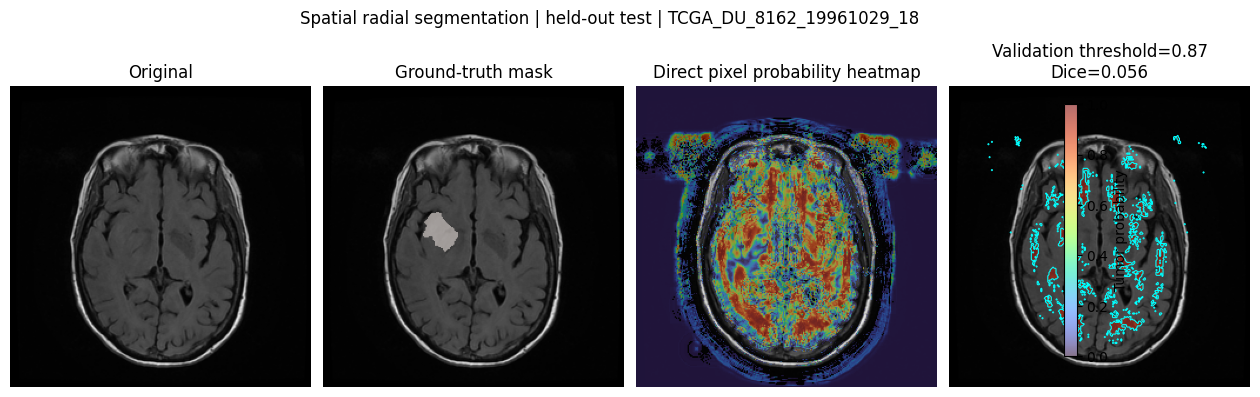

Saved spatial segmentation checkpoint, metrics, and heatmap to results/brain2_spatial_radial_segmentation


In [48]:
# ---------------- Direct spatial heatmap on a held-out positive test slice ----------------
positive_test_indices = [i for i, mask in enumerate(test_spatial_masks) if mask.any()]
if not positive_test_indices: raise RuntimeError("No tumor-positive test slice available for visualization")
spatial_example_index = positive_test_indices[0]
spatial_example_stem = test_spatial_stems[spatial_example_index]
spatial_example_row = next(r for r in spatial_test_rows if r["stem"] == spatial_example_stem)
spatial_example_image = image_to_gray_float(spatial_example_row["image"])
spatial_example_truth = test_spatial_masks[spatial_example_index]
spatial_example_prob = test_spatial_maps[spatial_example_index]
spatial_example_pred = spatial_example_prob >= spatial_threshold_result["threshold"]
tp_ex = int((spatial_example_pred & spatial_example_truth).sum())
fp_ex = int((spatial_example_pred & ~spatial_example_truth).sum())
fn_ex = int((~spatial_example_pred & spatial_example_truth).sum())
spatial_example_dice = 2.0 * tp_ex / max(1, 2 * tp_ex + fp_ex + fn_ex)

fig_spatial, axes = plt.subplots(1, 4, figsize=(16, 4.2))
axes[0].imshow(spatial_example_image, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(spatial_example_image, cmap="gray")
axes[1].imshow(np.ma.masked_where(~spatial_example_truth, spatial_example_truth), cmap="Reds", alpha=0.50)
axes[1].set_title("Ground-truth mask"); axes[1].axis("off")
axes[2].imshow(spatial_example_image, cmap="gray")
im_spatial = axes[2].imshow(np.ma.masked_where(spatial_example_prob < 0.02, spatial_example_prob),
                            cmap="turbo", alpha=0.58, vmin=0, vmax=1)
axes[2].set_title("Direct pixel probability heatmap"); axes[2].axis("off")
axes[3].imshow(spatial_example_image, cmap="gray")
axes[3].imshow(np.ma.masked_where(~spatial_example_pred, spatial_example_prob), cmap="turbo", alpha=0.60, vmin=0, vmax=1)
if spatial_example_pred.any(): axes[3].contour(spatial_example_pred, levels=[0.5], colors=["cyan"], linewidths=0.8)
axes[3].set_title(f"Validation threshold={spatial_threshold_result['threshold']:.2f}\nDice={spatial_example_dice:.3f}")
axes[3].axis("off")
fig_spatial.suptitle(f"Spatial radial segmentation | held-out test | {spatial_example_stem}", y=1.02)
fig_spatial.colorbar(im_spatial, ax=axes.ravel().tolist(), shrink=0.78, label="Tumor probability")
fig_spatial.subplots_adjust(wspace=0.04, top=0.85); plt.show()

torch.save({"model_state": spatial_model.state_dict(), "config": {
    "kernel_size": KERNEL_SIZE, "num_radial_kernels": NUM_RADIAL_KERNELS,
    "threshold": spatial_threshold_result["threshold"]}}, SPATIAL_OUT_DIR / "spatial_radial_checkpoint.pt")
np.save(SPATIAL_OUT_DIR / f"{spatial_example_stem}_probability.npy", spatial_example_prob.astype(np.float32))
np.save(SPATIAL_OUT_DIR / f"{spatial_example_stem}_prediction.npy", spatial_example_pred.astype(np.uint8))
fig_spatial.savefig(SPATIAL_OUT_DIR / f"{spatial_example_stem}_spatial_heatmap.png", dpi=240, bbox_inches="tight")
spatial_summary = {"best_epoch": best_spatial_state["epoch"],
                   "best_validation_soft_dice": best_spatial_state["val_soft_dice"],
                   "validation_threshold": spatial_threshold_result,
                   "test_metrics": test_spatial_metrics,
                   "example_stem": spatial_example_stem, "example_dice": spatial_example_dice,
                   "history": spatial_history}
(SPATIAL_OUT_DIR / "spatial_segmentation_summary.json").write_text(json.dumps(spatial_summary, indent=2))
print(f"Saved spatial segmentation checkpoint, metrics, and heatmap to {SPATIAL_OUT_DIR}")
